# Détection de Fraude dans les Transactions Financières
### Pipeline complet — Certificat en Intelligence Artificielle

**Sujet conçu par :** Khady KAMA   
**Auteur :** Rasmané  
**Dataset :** Cifer Fraud Detection Dataset-AF

Ce notebook regroupe l'intégralité du pipeline, de l'échantillonnage des données jusqu'à l'interface de démonstration, en passant par l'analyse exploratoire, le feature engineering, la modélisation, l'optimisation et l'interprétabilité SHAP.

> ⚠️ Résultat clé du projet : le diagnostic mené (sections 6 à 11) démontre que le signal prédictif disponible dans ce dataset est très faible (AUC-PR final ≈ 0,05, contre un seuil visé de 0,90). Voir la note méthodologique jointe pour le détail complet.

## Table des matières

1. Échantillonnage stratifié du dataset Cifer Fraud Detection
2. Contrôle qualité des données - Échantillon stratifié Cifer Fraud Detection
3. EDA détaillée - Échantillon stratifié Cifer Fraud Detection
4. Feature Engineering
5. Split stratifié train/val/test
6. Comparaison systématique : 4 modèles x 3 stratégies de déséquilibre
7. Diagnostic - AUC-PR proche du hasard
8. Optimisation des hyperparamètres - XGBoost (meilleure combinaison identifiée)
9. Évaluation finale sur l'ensemble de test
10. Interprétabilité SHAP 
11. Investigation du signal résiduel identifié par SHAP
12. Interface Gradio - Démonstration de détection de fraude

---

## 1. Échantillonnage stratifié du dataset Cifer Fraud Detection

Objectif : réduire 21M lignes à un échantillon exploitable sur 8 Go de RAM,
en gardant 100% des fraudes et un sous-échantillon aléatoire des non-fraudes.
 
Stratégie :
  - Lecture fichier par fichier (jamais les 14 CSV en mémoire en même temps)
  - Downcast des types dès la lecture (float64->float32, int64->int32/int8)
  - Séparation fraude / non-fraude à la volée, libération mémoire immédiate
  - Sous-échantillonnage aléatoire de la non-fraude (seed fixée = reproductible)
  - Ratio cible configurable (défaut : 50 non-fraudes pour 1 fraude)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import gc

### 0. CONFIGURATION

In [2]:
DOSSIER_DATA = r"C:\Users\hp\Documents\Fraude_detection\data"
CHEMIN_SORTIE = os.path.join(DOSSIER_DATA, "Cifer-echantillon-strat.csv")
 
RATIO_NON_FRAUDE_PAR_FRAUDE = 50   # 50:1 
SEED = 42                          # reproductibilité (exigence du sujet)
 
rng = np.random.default_rng(SEED)
 
# Types optimisés pour réduire l'empreinte mémoire dès la lecture
DTYPES = {
    "step": "int16",
    "type": "category",
    "amount": "float32",
    "nameOrig": "string",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "nameDest": "string",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

### 1. LOCALISER LES FICHIERS

In [3]:
motif = os.path.join(DOSSIER_DATA, "Cifer-Fraud-Detection-Dataset-AF-part-*.csv")
liste_fichiers = sorted(
    glob.glob(motif),
    key=lambda x: int(x.split("part-")[1].split("-")[0])
)
print(f"Nombre de fichiers trouvés : {len(liste_fichiers)}")
 
if len(liste_fichiers) == 0:
    raise FileNotFoundError("Aucun fichier trouvé. Vérifie DOSSIER_DATA et le motif.")

Nombre de fichiers trouvés : 14


### 2. PASSE 1 : EXTRAIRE TOUTES LES FRAUDES + COMPTER LES NON-FRAUDES

In [4]:
# On garde toutes les fraudes en mémoire (elles sont rares, ~27 500 lignes
# au total sur 21M -> volume négligeable).
# Pour la non-fraude, on fait un échantillonnage réservoir approximatif :
# on tire un sous-échantillon aléatoire à même chaque fichier, proportionnel
# à sa taille, pour ne jamais charger toute la non-fraude en mémoire.
 
liste_fraudes = []
liste_non_fraudes_echantillon = []
total_non_fraude_vu = 0
 
for i, fichier in enumerate(liste_fichiers, start=1):
    print(f"\nTraitement fichier {i}/{len(liste_fichiers)} : {os.path.basename(fichier)}")
 
    df = pd.read_csv(fichier, dtype=DTYPES)
    df["fichier_source"] = os.path.basename(fichier)
 
    # Séparer fraude / non-fraude dans ce fichier
    df_fraude = df[df["isFraud"] == 1]
    df_non_fraude = df[df["isFraud"] == 0]
 
    print(f"  Lignes : {len(df):,} | Fraudes : {len(df_fraude)} | "
          f"Non-fraudes : {len(df_non_fraude):,}")
 
    liste_fraudes.append(df_fraude.copy())
    total_non_fraude_vu += len(df_non_fraude)
 
    # Échantillonnage aléatoire immédiat de la non-fraude de CE fichier
    # (on suréchantillonne légèrement ici, le calibrage final se fait après
    # la passe 1 une fois qu'on connaît le nombre total de fraudes)
    taille_echantillon_fichier = min(len(df_non_fraude), 200_000)
    if len(df_non_fraude) > 0:
        echantillon = df_non_fraude.sample(
            n=taille_echantillon_fichier, random_state=SEED
        )
        liste_non_fraudes_echantillon.append(echantillon.copy())
 
    # Libération mémoire explicite avant de passer au fichier suivant
    del df, df_fraude, df_non_fraude
    gc.collect()


Traitement fichier 1/14 : Cifer-Fraud-Detection-Dataset-AF-part-1-14.csv
  Lignes : 1,500,000 | Fraudes : 1984 | Non-fraudes : 1,498,016

Traitement fichier 2/14 : Cifer-Fraud-Detection-Dataset-AF-part-2-14.csv
  Lignes : 1,500,000 | Fraudes : 1959 | Non-fraudes : 1,498,041

Traitement fichier 3/14 : Cifer-Fraud-Detection-Dataset-AF-part-3-14.csv
  Lignes : 1,500,000 | Fraudes : 2011 | Non-fraudes : 1,497,989

Traitement fichier 4/14 : Cifer-Fraud-Detection-Dataset-AF-part-4-14.csv
  Lignes : 1,500,000 | Fraudes : 1972 | Non-fraudes : 1,498,028

Traitement fichier 5/14 : Cifer-Fraud-Detection-Dataset-AF-part-5-14.csv
  Lignes : 1,500,000 | Fraudes : 2002 | Non-fraudes : 1,497,998

Traitement fichier 6/14 : Cifer-Fraud-Detection-Dataset-AF-part-6-14.csv
  Lignes : 1,500,000 | Fraudes : 1911 | Non-fraudes : 1,498,089

Traitement fichier 7/14 : Cifer-Fraud-Detection-Dataset-AF-part-7-14.csv
  Lignes : 1,500,000 | Fraudes : 1915 | Non-fraudes : 1,498,085

Traitement fichier 8/14 : Cifer-F

### 3. ASSEMBLER LES FRAUDES

In [5]:
data_fraude = pd.concat(liste_fraudes, ignore_index=True)
del liste_fraudes
gc.collect()
 
nb_fraudes_total = len(data_fraude)
print(f"\n{'='*70}")
print(f"Total fraudes collectées : {nb_fraudes_total:,}")
print(f"Total non-fraudes vues (tous fichiers) : {total_non_fraude_vu:,}")


Total fraudes collectées : 27,470
Total non-fraudes vues (tous fichiers) : 20,972,530


### 4. CALIBRER L'ÉCHANTILLON DE NON-FRAUDE AU RATIO CIBLE

In [6]:
nb_non_fraude_cible = nb_fraudes_total * RATIO_NON_FRAUDE_PAR_FRAUDE
print(f"Nombre de non-fraudes cible (ratio {RATIO_NON_FRAUDE_PAR_FRAUDE}:1) : "
      f"{nb_non_fraude_cible:,}")
 
data_non_fraude_brut = pd.concat(liste_non_fraudes_echantillon, ignore_index=True)
del liste_non_fraudes_echantillon
gc.collect()
 
print(f"Non-fraudes déjà pré-échantillonnées disponibles : {len(data_non_fraude_brut):,}")
 
if len(data_non_fraude_brut) >= nb_non_fraude_cible:
    # On a assez -> tirage final exact au ratio voulu
    data_non_fraude = data_non_fraude_brut.sample(
        n=int(nb_non_fraude_cible), random_state=SEED
    )
else:
    # Pas assez (cas rare si ratio très élevé) -> on garde tout ce qu'on a
    print("ATTENTION : pas assez de non-fraudes pré-échantillonnées pour")
    print("atteindre le ratio cible. Augmente taille_echantillon_fichier")
    print("dans la passe 1, ou réduis RATIO_NON_FRAUDE_PAR_FRAUDE.")
    data_non_fraude = data_non_fraude_brut
 
del data_non_fraude_brut
gc.collect()

Nombre de non-fraudes cible (ratio 50:1) : 1,373,500
Non-fraudes déjà pré-échantillonnées disponibles : 2,800,000


0

### 5. ASSEMBLER L'ÉCHANTILLON FINAL

In [7]:
data_echantillon = pd.concat([data_fraude, data_non_fraude], ignore_index=True)
# Mélanger les lignes (sinon toutes les fraudes sont regroupées au début)
data_echantillon = data_echantillon.sample(frac=1, random_state=SEED).reset_index(drop=True)
 
del data_fraude, data_non_fraude
gc.collect()
 
print(f"\n{'='*70}")
print("ÉCHANTILLON FINAL")
print(f"{'='*70}")
print(f"Lignes totales : {len(data_echantillon):,}")
print(f"Fraudes : {data_echantillon['isFraud'].sum():,}")
print(f"Non-fraudes : {(data_echantillon['isFraud']==0).sum():,}")
ratio_final = (data_echantillon['isFraud']==0).sum() / data_echantillon['isFraud'].sum()
print(f"Ratio final non-fraude:fraude : {ratio_final:.1f} : 1")
print(f"Taux de fraude dans l'échantillon : {data_echantillon['isFraud'].mean()*100:.3f}%")
 
# Empreinte mémoire de l'échantillon final
memoire_mo = data_echantillon.memory_usage(deep=True).sum() / 1024**2
print(f"Empreinte mémoire de l'échantillon : {memoire_mo:.1f} Mo")


ÉCHANTILLON FINAL
Lignes totales : 1,400,970
Fraudes : 27,470
Non-fraudes : 1,373,500
Ratio final non-fraude:fraude : 50.0 : 1
Taux de fraude dans l'échantillon : 1.961%
Empreinte mémoire de l'échantillon : 321.7 Mo


### 6. SAUVEGARDE

In [8]:
data_echantillon.to_csv(CHEMIN_SORTIE, index=False)
print(f"\nÉchantillon sauvegardé : {CHEMIN_SORTIE}")


Échantillon sauvegardé : C:\Users\hp\Documents\Fraude_detection\data\Cifer-echantillon-strat.csv


### 7. NOTE MÉTHODOLOGIQUE

In [10]:
print(f"""
{'='*70}
NOTE MÉTHODOLOGIQUE 
{'='*70}
Stratégie d'échantillonnage : échantillonnage stratifié asymétrique.
100% des transactions frauduleuses ont été conservées ({nb_fraudes_total:,}
lignes), car elles constituent la classe rare porteuse du signal principal.
Un sous-échantillon aléatoire (seed={SEED}, reproductible) de la classe
majoritaire a été tiré pour atteindre un ratio de {RATIO_NON_FRAUDE_PAR_FRAUDE}:1,
contre environ 763.5:1 dans le dataset
d'origine (valeur calculée lors de l'EDA initiale). Ce choix est motivé par une contrainte matérielle (8 Go de RAM)
tout en préservant un déséquilibre de classe réaliste et représentatif du
problème métier (~2% de fraude dans l'échantillon final vs <0.15% dans
l'ensemble complet). Le tirage aléatoire de la non-fraude a été effectué
fichier par fichier avant agrégation afin de représenter l'ensemble de la
période temporelle simulée (30 jours) et non uniquement une portion.
""")
 


NOTE MÉTHODOLOGIQUE 
Stratégie d'échantillonnage : échantillonnage stratifié asymétrique.
100% des transactions frauduleuses ont été conservées (27,470
lignes), car elles constituent la classe rare porteuse du signal principal.
Un sous-échantillon aléatoire (seed=42, reproductible) de la classe
majoritaire a été tiré pour atteindre un ratio de 50:1,
contre environ 763.5:1 dans le dataset
d'origine (valeur calculée lors de l'EDA initiale). Ce choix est motivé par une contrainte matérielle (8 Go de RAM)
tout en préservant un déséquilibre de classe réaliste et représentatif du
problème métier (~2% de fraude dans l'échantillon final vs <0.15% dans
l'ensemble complet). Le tirage aléatoire de la non-fraude a été effectué
fichier par fichier avant agrégation afin de représenter l'ensemble de la
période temporelle simulée (30 jours) et non uniquement une portion.



---

## 2. Contrôle qualité des données - Échantillon stratifié Cifer Fraud Detection

Couvre :
  1. Valeurs manquantes
  2. Doublons
  3. Valeurs extrêmes / aberrantes (outliers génériques, hors lien avec la fraude)
  4. Cohérence des types et des plages de valeurs
  5. Cohérence logique métier (valeurs négatives, incohérences structurelles)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
sns.set_theme(style="whitegrid")

DOSSIER_SORTIE = r"C:\Users\hp\Documents\Fraude_detection\data"

### 0. CHARGEMENT

In [12]:
CHEMIN_FICHIER = r"C:\Users\hp\Documents\Fraude_detection\data\Cifer-echantillon-strat.csv"

DTYPES = {
    "step": "int16",
    "type": "category",
    "amount": "float32",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

data1 = pd.read_csv(CHEMIN_FICHIER, dtype=DTYPES)
print(f"Échantillon chargé : {data1.shape[0]:,} lignes, {data1.shape[1]} colonnes\n")

Échantillon chargé : 1,400,970 lignes, 12 colonnes



### 1. VALEURS MANQUANTES

In [13]:
print("=" * 70)
print("1. VALEURS MANQUANTES")
print("=" * 70)

manquants = data1.isnull().sum()
pct_manquants = (manquants / len(data1) * 100).round(3)
tableau_manquants = pd.DataFrame({
    "nb_manquants": manquants,
    "pct_manquants": pct_manquants
}).sort_values("nb_manquants", ascending=False)

print(tableau_manquants)

if tableau_manquants["nb_manquants"].sum() == 0:
    print("\nAucune valeur manquante détectée sur l'échantillon.")
else:
    print(f"\nColonnes avec des manquants :")
    print(tableau_manquants[tableau_manquants["nb_manquants"] > 0])

    # Visualisation type "carte des manquants" si des colonnes sont concernées
    colonnes_avec_manquants = tableau_manquants[tableau_manquants["nb_manquants"] > 0].index.tolist()
    if colonnes_avec_manquants:
        plt.figure(figsize=(10, 5))
        sns.heatmap(data1[colonnes_avec_manquants].isnull(), cbar=False, cmap="Reds")
        plt.title("Carte des valeurs manquantes")
        plt.tight_layout()
        plt.savefig(f"{DOSSIER_SORTIE}/qc_valeurs_manquantes.png", dpi=120)
        #plt.close()
        print("Graphique sauvegardé : qc_valeurs_manquantes.png")

        # Manquants croisés avec isFraud : un manquant n'est jamais "aléatoire"
        # par hasard en fraude, toujours vérifier s'il est corrélé à la cible
        print("\nTaux de fraude selon présence de valeurs manquantes :")
        for col in colonnes_avec_manquants:
            masque_manquant = data1[col].isnull()
            taux_avec = data1.loc[masque_manquant, "isFraud"].mean()
            taux_sans = data1.loc[~masque_manquant, "isFraud"].mean()
            print(f"  {col} : manquant -> {taux_avec*100:.3f}% fraude | "
                  f"non-manquant -> {taux_sans*100:.3f}% fraude")

1. VALEURS MANQUANTES
                nb_manquants  pct_manquants
step                       0            0.0
type                       0            0.0
amount                     0            0.0
nameOrig                   0            0.0
oldbalanceOrg              0            0.0
newbalanceOrig             0            0.0
nameDest                   0            0.0
oldbalanceDest             0            0.0
newbalanceDest             0            0.0
isFraud                    0            0.0
isFlaggedFraud             0            0.0
fichier_source             0            0.0

Aucune valeur manquante détectée sur l'échantillon.


### 2. DOUBLONS

In [15]:
print("\n" + "=" * 70)
print("2. DOUBLONS")
print("=" * 70)

# 2.1 Doublons stricts (toutes colonnes identiques)
nb_doublons_stricts = data1.duplicated().sum()
print(f"\n2.1 Doublons stricts (toutes colonnes) : {nb_doublons_stricts:,} "
      f"({nb_doublons_stricts/len(data1)*100:.4f}%)")

# 2.2 Doublons hors colonne technique fichier_source (si présente)
if "fichier_source" in data1.columns:
    nb_doublons_hors_source = data1.drop(columns=["fichier_source"]).duplicated().sum()
    print(f"2.2 Doublons hors 'fichier_source' : {nb_doublons_hors_source:,} "
          f"({nb_doublons_hors_source/len(data1)*100:.4f}%)")

# 2.3 Doublons sur les colonnes métier uniquement (hors identifiants,
# car nameOrig/nameDest sont uniques par construction sur données synthétiques)
colonnes_metier = ["step", "type", "amount", "oldbalanceOrg", "newbalanceOrig",
                    "oldbalanceDest", "newbalanceDest", "isFraud"]
colonnes_metier_presentes = [c for c in colonnes_metier if c in data1.columns]
nb_doublons_metier = data1.duplicated(subset=colonnes_metier_presentes).sum()
print(f"2.3 Doublons sur variables métier uniquement (hors ID) : {nb_doublons_metier:,} "
      f"({nb_doublons_metier/len(data1)*100:.4f}%)")
if nb_doublons_stricts > 0:
    print("\nAperçu de quelques lignes dupliquées :")
    print(data1[data1.duplicated(keep=False)].sort_values(
        by=colonnes_metier_presentes[0]).head(10))


2. DOUBLONS

2.1 Doublons stricts (toutes colonnes) : 0 (0.0000%)
2.2 Doublons hors 'fichier_source' : 0 (0.0000%)
2.3 Doublons sur variables métier uniquement (hors ID) : 0 (0.0000%)


### 3. VALEURS EXTRÊMES / ABERRANTES (génériques, hors lien avec la fraude)


3. VALEURS EXTRÊMES ET ABERRANTES

3.1 Plage de valeurs par colonne numérique :
                 min          max        mean      median          std
step            1.00        743.0      238.77      205.00       163.28
amount          0.00    4698194.5   180028.28    82529.69    253327.47
oldbalanceOrg   0.01   34869764.0  1338441.75   216155.58   2578722.75
newbalanceOrig  0.00   36743044.0  2088327.38   586109.00   3414232.00
oldbalanceDest  0.01   41295480.0  1939385.25  1011542.88   2506670.00
newbalanceDest  0.00  235702384.0  3753624.00    64581.12  10339215.00

3.2 Valeurs négatives détectées :
  step : aucune valeur négative (cohérent)
  amount : aucune valeur négative (cohérent)
  oldbalanceOrg : aucune valeur négative (cohérent)
  newbalanceOrig : aucune valeur négative (cohérent)
  oldbalanceDest : aucune valeur négative (cohérent)
  newbalanceDest : aucune valeur négative (cohérent)

3.3 Fréquence des valeurs à zéro :
  step : 0 zéros (0.00%)
  amount : 1,979 zéros (0.1

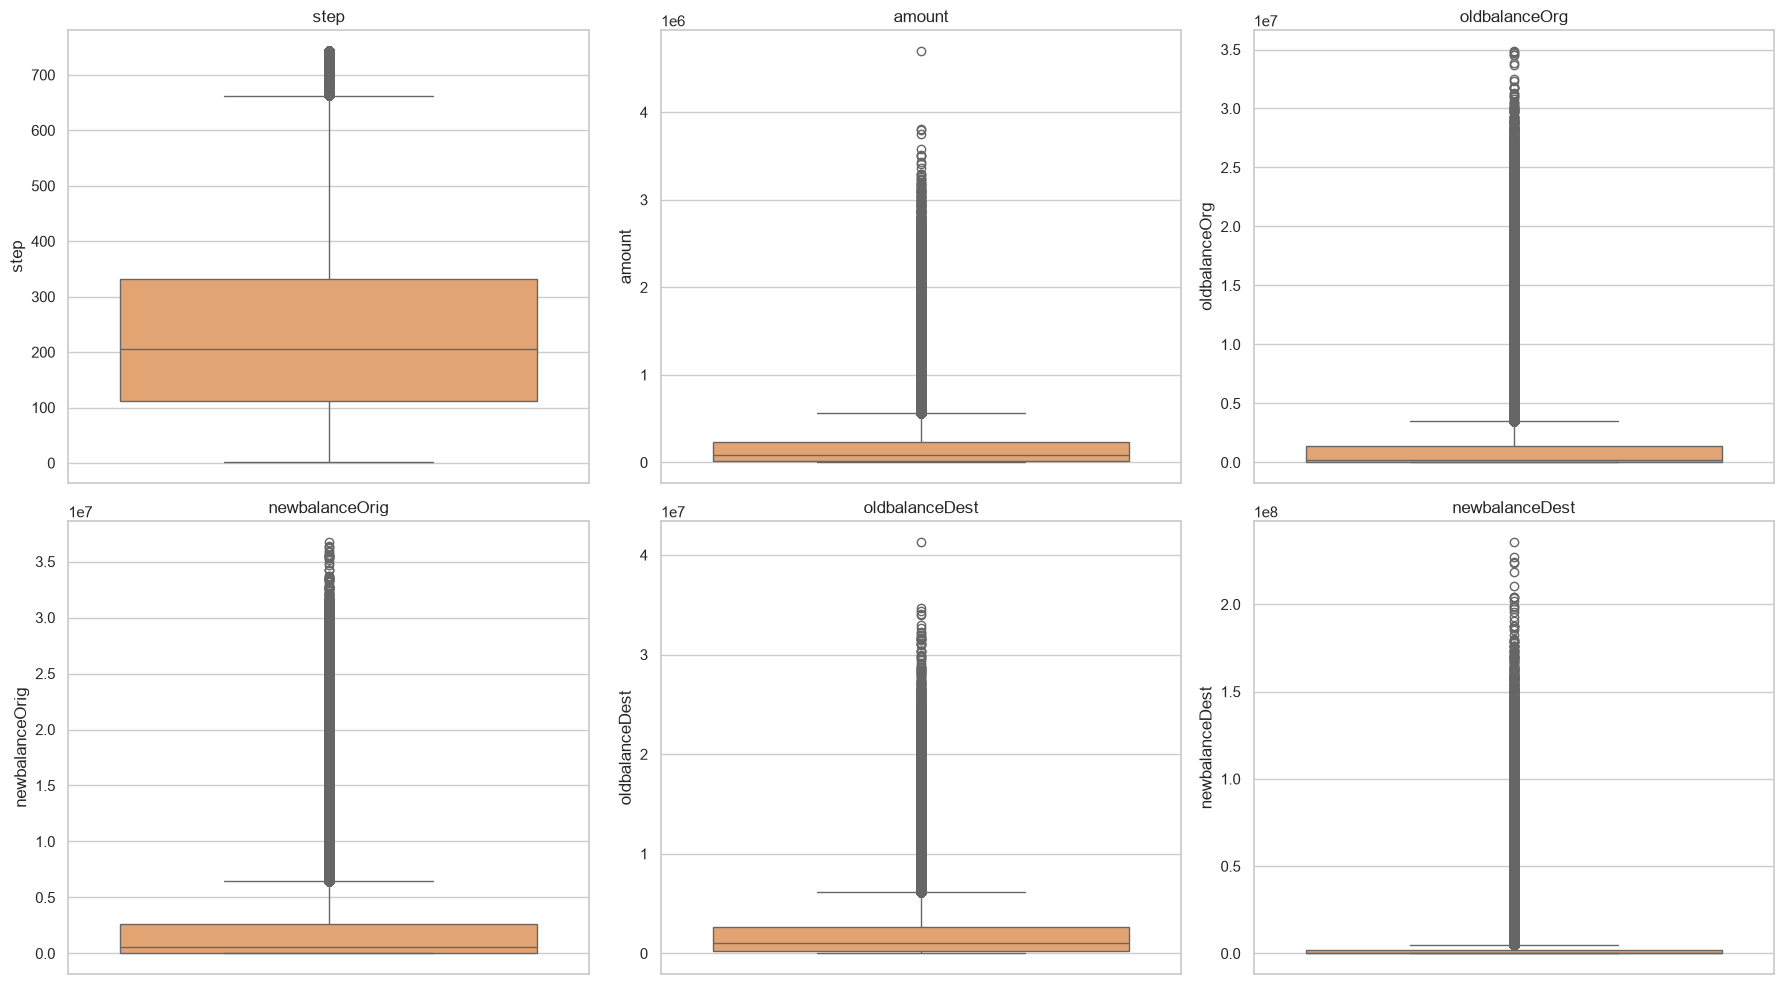

In [16]:
print("\n" + "=" * 70)
print("3. VALEURS EXTRÊMES ET ABERRANTES")
print("=" * 70)

colonnes_num = ["step", "amount", "oldbalanceOrg", "newbalanceOrig",
                 "oldbalanceDest", "newbalanceDest"]
colonnes_num = [c for c in colonnes_num if c in data1.columns]

# 3.1 Min / max / plage de valeurs (détecter des valeurs impossibles)
print("\n3.1 Plage de valeurs par colonne numérique :")
plage_valeurs = data1[colonnes_num].agg(["min", "max", "mean", "median", "std"]).T
print(plage_valeurs.round(2))

# 3.2 Valeurs négatives (impossibles pour montants/soldes)
print("\n3.2 Valeurs négatives détectées :")
for col in colonnes_num:
    nb_negatifs = (data1[col] < 0).sum()
    if nb_negatifs > 0:
        print(f"  {col} : {nb_negatifs:,} valeurs négatives "
              f"({nb_negatifs/len(data1)*100:.4f}%) -> ANOMALIE À INVESTIGUER")
    else:
        print(f"  {col} : aucune valeur négative (cohérent)")

# 3.3 Valeurs exactement nulles (0) - fréquence, pas anormal en soi mais à quantifier
print("\n3.3 Fréquence des valeurs à zéro :")
for col in colonnes_num:
    nb_zeros = (data1[col] == 0).sum()
    print(f"  {col} : {nb_zeros:,} zéros ({nb_zeros/len(data1)*100:.2f}%)")

# 3.4 Détection IQR générique (sans lien avec isFraud - vision "qualité pure")
print("\n3.4 Détection d'outliers via IQR (vision qualité, indépendante de isFraud) :")
resultats_iqr = []
for col in colonnes_num:
    q1, q3 = data1[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    borne_inf = q1 - 1.5 * iqr
    borne_sup = q3 + 1.5 * iqr
    nb_outliers = ((data1[col] < borne_inf) | (data1[col] > borne_sup)).sum()
    resultats_iqr.append({
        "variable": col,
        "borne_inf": round(borne_inf, 2),
        "borne_sup": round(borne_sup, 2),
        "nb_outliers": nb_outliers,
        "pct_outliers": round(nb_outliers / len(data1) * 100, 2)
    })
df_iqr = pd.DataFrame(resultats_iqr)
print(df_iqr)

# 3.5 Détection par z-score (méthode complémentaire, plus sensible aux extrêmes)
print("\n3.5 Détection d'outliers via z-score (|z| > 3) :")
resultats_zscore = []
for col in colonnes_num:
    moyenne = data1[col].mean()
    ecart_type = data1[col].std()
    z_scores = (data1[col] - moyenne) / ecart_type
    nb_extremes = (z_scores.abs() > 3).sum()
    resultats_zscore.append({
        "variable": col,
        "nb_extremes_zscore": nb_extremes,
        "pct_extremes_zscore": round(nb_extremes / len(data1) * 100, 2)
    })
df_zscore = pd.DataFrame(resultats_zscore)
print(df_zscore)
print("-> Le z-score est plus conservateur que l'IQR sur des distributions")
print("   très asymétriques (typique des montants financiers) ; comparer")
print("   les deux donne une idée de la sensibilité de chaque méthode ici.")

# 3.6 Visualisation boxplots génériques
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(colonnes_num):
    sns.boxplot(y=data1[col], ax=axes[i], color="#F4A261")
    axes[i].set_title(f"{col}")
for j in range(len(colonnes_num), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig(f"{DOSSIER_SORTIE}/qc_boxplots_generiques.png", dpi=120)
#plt.close()
print("\nGraphique sauvegardé : qc_boxplots_generiques.png")

# 3.7 step hors plage attendue (0-743 pour 744 steps / 30 jours)
if "step" in data1.columns:
    print("\n3.7 Vérification de la plage de 'step' (attendu : 0 à 743 inclus)")
    step_min, step_max = data1["step"].min(), data1["step"].max()
    print(f"  step min = {step_min}, step max = {step_max}")
    if step_min < 0 or step_max > 743:
        print("  ANOMALIE : step hors de la plage attendue (30 jours = 744 steps).")
    else:
        print("  Cohérent avec la période simulée de 30 jours.")

### 4. COHÉRENCE DES TYPES DE DONNÉES

In [17]:
print("\n" + "=" * 70)
print("4. COHÉRENCE DES TYPES DE DONNÉES")
print("=" * 70)
print(data1.dtypes)

# Valeurs de 'type' effectivement présentes vs valeurs attendues du sujet
if "type" in data1.columns:
    types_attendus = {"CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"}
    types_presents = set(data1["type"].unique())
    print(f"\nTypes attendus (sujet) : {types_attendus}")
    print(f"Types présents (données) : {types_presents}")
    types_inattendus = types_presents - types_attendus
    types_manquants = types_attendus - types_presents
    if types_inattendus:
        print(f"ATTENTION - types inattendus trouvés : {types_inattendus}")
    if types_manquants:
        print(f"Types attendus mais absents de l'échantillon : {types_manquants}")
    if not types_inattendus and not types_manquants:
        print("Cohérent : tous les types attendus sont présents, aucun type inattendu.")

# isFraud et isFlaggedFraud : vérifier que ce sont bien des binaires 0/1
for col in ["isFraud", "isFlaggedFraud"]:
    if col in data1.columns:
        valeurs_uniques = sorted(data1[col].unique())
        statut = "OK (binaire 0/1)" if valeurs_uniques == [0, 1] else "ANOMALIE"
        print(f"\n{col} : valeurs uniques = {valeurs_uniques} -> {statut}")


4. COHÉRENCE DES TYPES DE DONNÉES
step                 int16
type              category
amount             float32
nameOrig               str
oldbalanceOrg      float32
newbalanceOrig     float32
nameDest               str
oldbalanceDest     float32
newbalanceDest     float32
isFraud               int8
isFlaggedFraud        int8
fichier_source         str
dtype: object

Types attendus (sujet) : {'CASH_IN', 'DEBIT', 'CASH_OUT', 'PAYMENT', 'TRANSFER'}
Types présents (données) : {'CASH_IN', 'DEBIT', 'CASH_OUT', 'PAYMENT', 'TRANSFER'}
Cohérent : tous les types attendus sont présents, aucun type inattendu.

isFraud : valeurs uniques = [np.int8(0), np.int8(1)] -> OK (binaire 0/1)

isFlaggedFraud : valeurs uniques = [np.int8(0), np.int8(1)] -> OK (binaire 0/1)


### 5. COHÉRENCE LOGIQUE MÉTIER

In [18]:
print("\n" + "=" * 70)
print("5. COHÉRENCE LOGIQUE MÉTIER")
print("=" * 70)

# 5.1 Transactions à montant nul
nb_montant_nul = (data1["amount"] == 0).sum()
print(f"\n5.1 Transactions avec montant = 0 : {nb_montant_nul:,} "
      f"({nb_montant_nul/len(data1)*100:.4f}%)")
if nb_montant_nul > 0:
    print(f"  Dont frauduleuses : {data1.loc[data1['amount']==0, 'isFraud'].sum()}")

# 5.2 Cohérence comptable émetteur : newbalanceOrig = oldbalanceOrg - amount
print("\n5.2 Cohérence comptable émetteur (écart |oldbalanceOrg - amount - newbalanceOrig|)")
data1["ecart_balance_orig"] = (
    data1["oldbalanceOrg"] - data1["amount"] - data1["newbalanceOrig"]
).abs()
tolerance = 1  # tolérance d'arrondi
nb_incoherent_orig = (data1["ecart_balance_orig"] > tolerance).sum()
print(f"  Transactions incohérentes (écart > {tolerance}) : {nb_incoherent_orig:,} "
      f"({nb_incoherent_orig/len(data1)*100:.2f}%)")
print(f"  Écart moyen : {data1['ecart_balance_orig'].mean():.2f}")
print(f"  Écart médian : {data1['ecart_balance_orig'].median():.2f}")
print(f"  Écart max : {data1['ecart_balance_orig'].max():.2f}")

# 5.3 Cohérence comptable destinataire : newbalanceDest = oldbalanceDest + amount
print("\n5.3 Cohérence comptable destinataire (écart |oldbalanceDest + amount - newbalanceDest|)")
data1["ecart_balance_dest"] = (
    data1["oldbalanceDest"] + data1["amount"] - data1["newbalanceDest"]
).abs()
nb_incoherent_dest = (data1["ecart_balance_dest"] > tolerance).sum()
print(f"  Transactions incohérentes (écart > {tolerance}) : {nb_incoherent_dest:,} "
      f"({nb_incoherent_dest/len(data1)*100:.2f}%)")
print(f"  Écart moyen : {data1['ecart_balance_dest'].mean():.2f}")
print(f"  Écart médian : {data1['ecart_balance_dest'].median():.2f}")

print("\nInterprétation : ces écarts confirment ou infirment la fidélité du")
print("simulateur Cifer par rapport à la logique comptable stricte de PaySim.")
print("Si le taux d'incohérence est élevé, documenter cette limite dans le")
print("rapport (section 'limites du projet' exigée par le sujet, point 19),")
print("et rester prudent sur l'usage de features dérivées de ces écarts.")


5. COHÉRENCE LOGIQUE MÉTIER

5.1 Transactions avec montant = 0 : 1,979 (0.1413%)
  Dont frauduleuses : 22

5.2 Cohérence comptable émetteur (écart |oldbalanceOrg - amount - newbalanceOrig|)
  Transactions incohérentes (écart > 1) : 1,400,957 (100.00%)
  Écart moyen : 1589524.88
  Écart médian : 645690.56
  Écart max : 29270176.00

5.3 Cohérence comptable destinataire (écart |oldbalanceDest + amount - newbalanceDest|)
  Transactions incohérentes (écart > 1) : 1,400,920 (100.00%)
  Écart moyen : 3212102.50
  Écart médian : 846961.81

Interprétation : ces écarts confirment ou infirment la fidélité du
simulateur Cifer par rapport à la logique comptable stricte de PaySim.
Si le taux d'incohérence est élevé, documenter cette limite dans le
rapport (section 'limites du projet' exigée par le sujet, point 19),
et rester prudent sur l'usage de features dérivées de ces écarts.


### 6. RÉCAPITULATIF FINAL

In [19]:
print("\n" + "=" * 70)
print("6. RÉCAPITULATIF QUALITÉ DES DONNÉES")
print("=" * 70)
print(f"- Lignes analysées : {len(data1):,}")
print(f"- Valeurs manquantes totales : {int(tableau_manquants['nb_manquants'].sum())}")
print(f"- Doublons stricts : {nb_doublons_stricts:,}")
print(f"- Valeurs négatives détectées : "
      f"{sum((data1[c] < 0).sum() for c in colonnes_num)}")
print(f"- Incohérences comptables émetteur : {nb_incoherent_orig:,} "
      f"({nb_incoherent_orig/len(data1)*100:.2f}%)")
print(f"- Incohérences comptables destinataire : {nb_incoherent_dest:,} "
      f"({nb_incoherent_dest/len(data1)*100:.2f}%)")
print("\nContrôle qualité terminé — résultats prêts pour la section")
print("'qualité des données' du rapport et pour orienter le nettoyage")
print("avant le feature engineering.")


6. RÉCAPITULATIF QUALITÉ DES DONNÉES
- Lignes analysées : 1,400,970
- Valeurs manquantes totales : 0
- Doublons stricts : 0
- Valeurs négatives détectées : 0
- Incohérences comptables émetteur : 1,400,957 (100.00%)
- Incohérences comptables destinataire : 1,400,920 (100.00%)

Contrôle qualité terminé — résultats prêts pour la section
'qualité des données' du rapport et pour orienter le nettoyage
avant le feature engineering.


---

## 3. EDA détaillée - Échantillon stratifié Cifer Fraud Detection
 
5 axes d'analyse :
  1. Distribution des types de transactions et lien avec la fraude
  2. Déséquilibre de classes + répartition temporelle des fraudes
  3. Distribution des montants/soldes + patterns de fraude
  4. Corrélations entre variables et avec isFraud
  5. Analyse de isFlaggedFraud vs isFraud


In [20]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
sns.set_theme(style="whitegrid")
DOSSIER_SORTIE = r"C:\Users\hp\Documents\Fraude_detection\data"

### 0. CHARGEMENT DE L'ÉCHANTILLON STRATIFIÉ

In [21]:
CHEMIN_FICHIER = r"C:\Users\hp\Documents\Fraude_detection\data\Cifer-echantillon-strat.csv"
 
DTYPES = {
    "step": "int16",
    "type": "category",
    "amount": "float32",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}
 
data1 = pd.read_csv(CHEMIN_FICHIER, dtype=DTYPES)
print(f"Échantillon chargé : {data1.shape[0]:,} lignes, {data1.shape[1]} colonnes")
print(f"Empreinte mémoire : {data1.memory_usage(deep=True).sum() / 1024**2:.1f} Mo")
print(data1.columns.tolist())
 
# Rappel : cet échantillon N'EST PAS le dataset complet.
# Le ratio de déséquilibre ici (~50:1) est différent du ratio réel du
# dataset d'origine (~763:1)
ratio_echantillon = (data1["isFraud"] == 0).sum() / (data1["isFraud"] == 1).sum()
print(f"\nRatio de déséquilibre DANS CET ÉCHANTILLON : {ratio_echantillon:.1f} : 1")
print("(rappel : ratio réel dans le dataset complet ~763.5 : 1, cf. EDA sur fichiers bruts)")

Échantillon chargé : 1,400,970 lignes, 12 colonnes
Empreinte mémoire : 321.7 Mo
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'fichier_source']

Ratio de déséquilibre DANS CET ÉCHANTILLON : 50.0 : 1
(rappel : ratio réel dans le dataset complet ~763.5 : 1, cf. EDA sur fichiers bruts)


### AXE 1 — DISTRIBUTION DES TYPES DE TRANSACTIONS ET LIEN AVEC LA FRAUDE


AXE 1 : TYPES DE TRANSACTIONS ET FRAUDE

1.1 Répartition globale par type (dans l'échantillon) :
          nb_transactions  pct_transactions
type                                       
CASH_OUT           493261            35.209
PAYMENT            473551            33.802
CASH_IN            307797            21.970
TRANSFER           117111             8.359
DEBIT                9250             0.660

1.2 Fraude par type de transaction :
          nb_fraudes  nb_transactions  taux_fraude  taux_fraude_pct
type                                                               
CASH_OUT        9751           493261     0.019768           1.9768
PAYMENT         9271           473551     0.019578           1.9578
CASH_IN         6028           307797     0.019584           1.9584
TRANSFER        2214           117111     0.018905           1.8905
DEBIT            206             9250     0.022270           2.2270

Types concernés par au moins une fraude : ['CASH_OUT', 'PAYMENT', 'CASH_IN', 'T

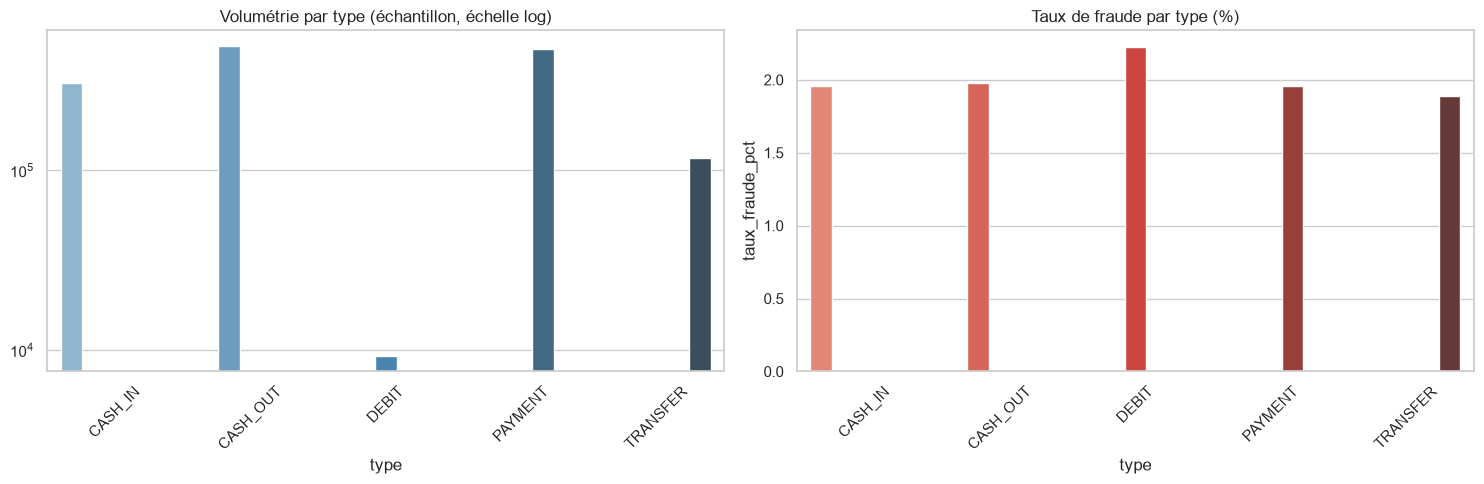

In [22]:
print("\n" + "=" * 70)
print("AXE 1 : TYPES DE TRANSACTIONS ET FRAUDE")
print("=" * 70)
 
repartition_types = data1["type"].value_counts()
repartition_types_pct = data1["type"].value_counts(normalize=True) * 100
tableau_types = pd.DataFrame({
    "nb_transactions": repartition_types,
    "pct_transactions": repartition_types_pct.round(3)
})
print("\n1.1 Répartition globale par type (dans l'échantillon) :")
print(tableau_types)
 
tableau_fraude_type = data1.groupby("type", observed=True)["isFraud"].agg(
    nb_fraudes="sum", nb_transactions="count", taux_fraude="mean"
)
tableau_fraude_type["taux_fraude_pct"] = (tableau_fraude_type["taux_fraude"] * 100).round(4)
tableau_fraude_type = tableau_fraude_type.sort_values("nb_fraudes", ascending=False)
print("\n1.2 Fraude par type de transaction :")
print(tableau_fraude_type)
 
types_avec_fraude = tableau_fraude_type[tableau_fraude_type["nb_fraudes"] > 0].index.tolist()
print(f"\nTypes concernés par au moins une fraude : {types_avec_fraude}")
 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=repartition_types.index, y=repartition_types.values,
            ax=axes[0], hue=repartition_types.index, palette="Blues_d", legend=False)
axes[0].set_yscale("log")
axes[0].set_title("Volumétrie par type (échantillon, échelle log)")
axes[0].tick_params(axis="x", rotation=45)
 
sns.barplot(x=tableau_fraude_type.index, y=tableau_fraude_type["taux_fraude_pct"],
            ax=axes[1], hue=tableau_fraude_type.index, palette="Reds_d", legend=False)
axes[1].set_title("Taux de fraude par type (%)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(f"{DOSSIER_SORTIE}/axe1_types_transactions.png", dpi=120)
#plt.close()
print("Graphique sauvegardé : axe1_types_transactions.png")
 
if types_avec_fraude:
    sous_ensemble = data1[data1["type"].isin(types_avec_fraude)]
    print(f"\n1.4 Volume concerné par les types frauduleux : {len(sous_ensemble):,} "
          f"({len(sous_ensemble)/len(data1)*100:.1f}% de l'échantillon)")
    print(f"Taux de fraude sur ce sous-ensemble : {sous_ensemble['isFraud'].mean()*100:.4f}%")

### AXE 2 — DÉSÉQUILIBRE DE CLASSES + RÉPARTITION TEMPORELLE


AXE 2 : DÉSÉQUILIBRE DE CLASSES ET RÉPARTITION TEMPORELLE

2.1 Répartition de la cible (échantillon) :
isFraud
0    1373500
1      27470
Name: count, dtype: int64
Pourcentage de fraude dans l'échantillon : 1.9608%
Ratio de déséquilibre échantillon : 50.0 : 1
ATTENTION : ce ratio résulte du sous-échantillonnage volontaire de la
non-fraude (RAM limitée à 8 Go) -> ne pas le confondre avec le ratio
réel du dataset complet (~763.5:1), à toujours mentionner ensemble
dans le rapport pour ne pas fausser la lecture de la sévérité réelle.
Graphique sauvegardé : axe2_desequilibre_classes.png

2.3 Répartition temporelle des fraudes (step = 1 heure, 744 steps = 30 jours) :
Nombre de steps distincts dans l'échantillon : 743 / 744
Step avec le plus de fraudes en absolu : 743 (255 fraudes)
Step avec le taux de fraude le plus élevé : 698 (4.74%)
Graphique sauvegardé : axe2_repartition_temporelle.png

Taux de fraude par heure du jour (step % 24) :
heure_du_jour
0     1.9973
1     1.9500
2     1.9565
3 

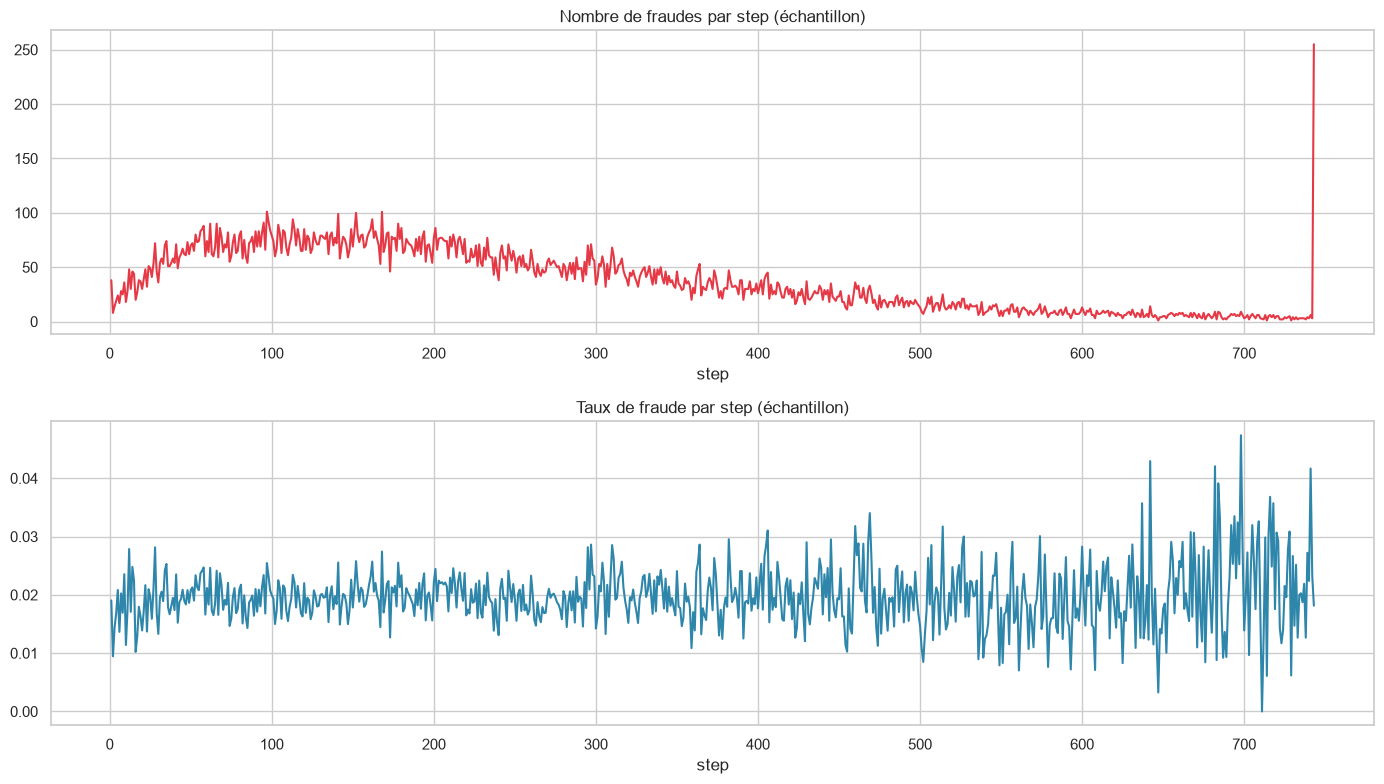

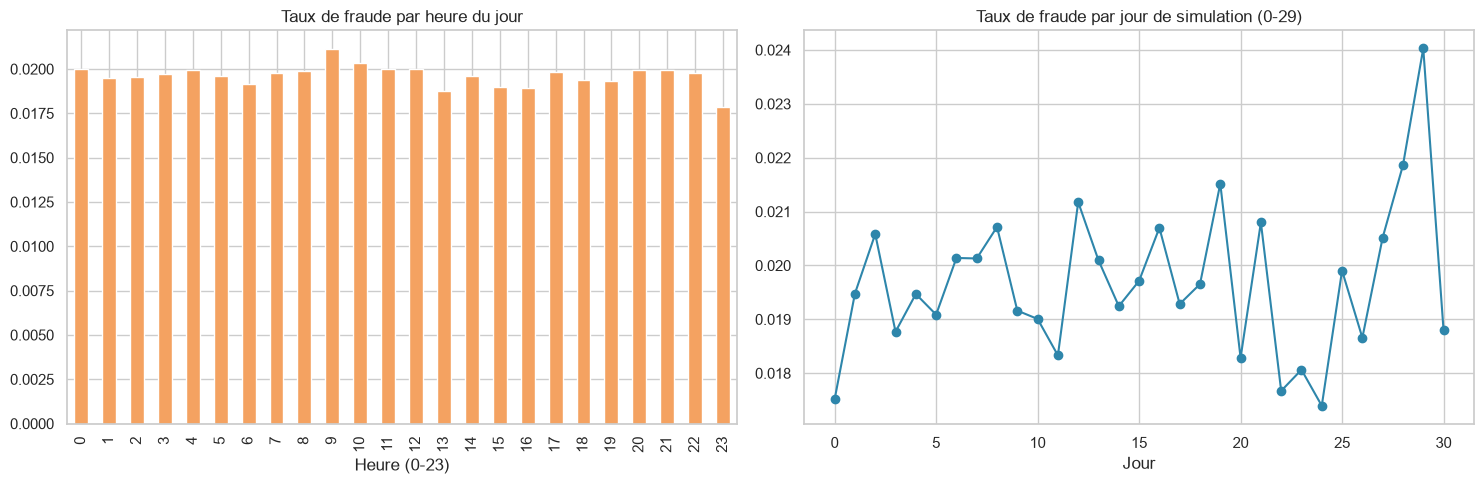

In [23]:
print("\n" + "=" * 70)
print("AXE 2 : DÉSÉQUILIBRE DE CLASSES ET RÉPARTITION TEMPORELLE")
print("=" * 70)
 
effectifs_cible = data1["isFraud"].value_counts()
print(f"\n2.1 Répartition de la cible (échantillon) :")
print(effectifs_cible)
print(f"Pourcentage de fraude dans l'échantillon : {data1['isFraud'].mean()*100:.4f}%")
print(f"Ratio de déséquilibre échantillon : {ratio_echantillon:.1f} : 1")
print("ATTENTION : ce ratio résulte du sous-échantillonnage volontaire de la")
print("non-fraude (RAM limitée à 8 Go) -> ne pas le confondre avec le ratio")
print("réel du dataset complet (~763.5:1), à toujours mentionner ensemble")
print("dans le rapport pour ne pas fausser la lecture de la sévérité réelle.")
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
effectifs_cible.plot(kind="bar", ax=axes[0], color=["#2E86AB", "#E63946"])
axes[0].set_title("Répartition des classes (échantillon)")
axes[0].set_xticklabels(["Non-fraude (0)", "Fraude (1)"], rotation=0)
axes[1].pie(effectifs_cible, labels=["Non-fraude", "Fraude"], autopct="%1.2f%%",
            colors=["#2E86AB", "#E63946"])
axes[1].set_title("Répartition des classes (%)")
plt.tight_layout()
plt.savefig(f"{DOSSIER_SORTIE}/axe2_desequilibre_classes.png", dpi=120)
plt.close()
print("Graphique sauvegardé : axe2_desequilibre_classes.png")
 
if "step" in data1.columns:
    print("\n2.3 Répartition temporelle des fraudes (step = 1 heure, 744 steps = 30 jours) :")
    fraudes_par_step = data1[data1["isFraud"] == 1].groupby("step").size()
    taux_par_step = data1.groupby("step")["isFraud"].mean()
 
    print(f"Nombre de steps distincts dans l'échantillon : {data1['step'].nunique()} / 744")
    print(f"Step avec le plus de fraudes en absolu : {fraudes_par_step.idxmax()} "
          f"({fraudes_par_step.max()} fraudes)")
    print(f"Step avec le taux de fraude le plus élevé : {taux_par_step.idxmax()} "
          f"({taux_par_step.max()*100:.2f}%)")
 
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fraudes_par_step.plot(ax=axes[0], color="#E63946")
    axes[0].set_title("Nombre de fraudes par step (échantillon)")
    axes[0].set_xlabel("step")
    taux_par_step.plot(ax=axes[1], color="#2E86AB")
    axes[1].set_title("Taux de fraude par step (échantillon)")
    axes[1].set_xlabel("step")
    plt.tight_layout()
    plt.savefig(f"{DOSSIER_SORTIE}/axe2_repartition_temporelle.png", dpi=120)
    #plt.close()
    print("Graphique sauvegardé : axe2_repartition_temporelle.png")
 
    # Heure du jour (step % 24) et jour de la semaine (step // 24 % 7)
    data1["heure_du_jour"] = data1["step"] % 24
    data1["jour_simulation"] = data1["step"] // 24
 
    taux_par_heure = data1.groupby("heure_du_jour")["isFraud"].mean()
    print("\nTaux de fraude par heure du jour (step % 24) :")
    print((taux_par_heure * 100).round(4))
 
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    taux_par_heure.plot(kind="bar", ax=axes[0], color="#F4A261")
    axes[0].set_title("Taux de fraude par heure du jour")
    axes[0].set_xlabel("Heure (0-23)")
 
    taux_par_jour = data1.groupby("jour_simulation")["isFraud"].mean()
    taux_par_jour.plot(ax=axes[1], color="#2E86AB", marker="o")
    axes[1].set_title("Taux de fraude par jour de simulation (0-29)")
    axes[1].set_xlabel("Jour")
    plt.tight_layout()
    plt.savefig(f"{DOSSIER_SORTIE}/axe2_taux_par_heure_et_jour.png", dpi=120)
    #plt.close()
    print("Graphique sauvegardé : axe2_taux_par_heure_et_jour.png")
else:
    print("Colonne 'step' absente.")

### AXE 3 — DISTRIBUTION DES MONTANTS/SOLDES + PATTERNS DE FRAUDE


AXE 3 : MONTANTS, SOLDES ET PATTERNS DE FRAUDE

3.1 Statistiques descriptives par classe :

--- amount ---
       non_fraude      fraude
count  1373500.00    27470.00
mean    179915.86   185649.52
std     253240.92   257559.88
min          0.00        0.00
25%      18634.40    20267.01
50%      82421.35    88542.23
75%     238569.84   249061.89
max    4698194.50  2803635.25

--- oldbalanceOrg ---
        non_fraude       fraude
count   1373500.00     27470.00
mean    1337693.88   1375839.88
std     2577913.50   2618643.00
min           0.01         0.01
25%       10668.28     11622.15
50%      215962.55    226076.62
75%     1422160.19   1472023.56
max    34869764.00  29703626.00

--- newbalanceOrig ---
        non_fraude       fraude
count   1373500.00     27470.00
mean    2088563.38   2076526.88
std     3413688.25   3441348.00
min           0.00         0.00
25%       58827.32     58678.98
50%      586638.12    564143.62
75%     2606601.12   2535910.19
max    36743044.00  31037738.00

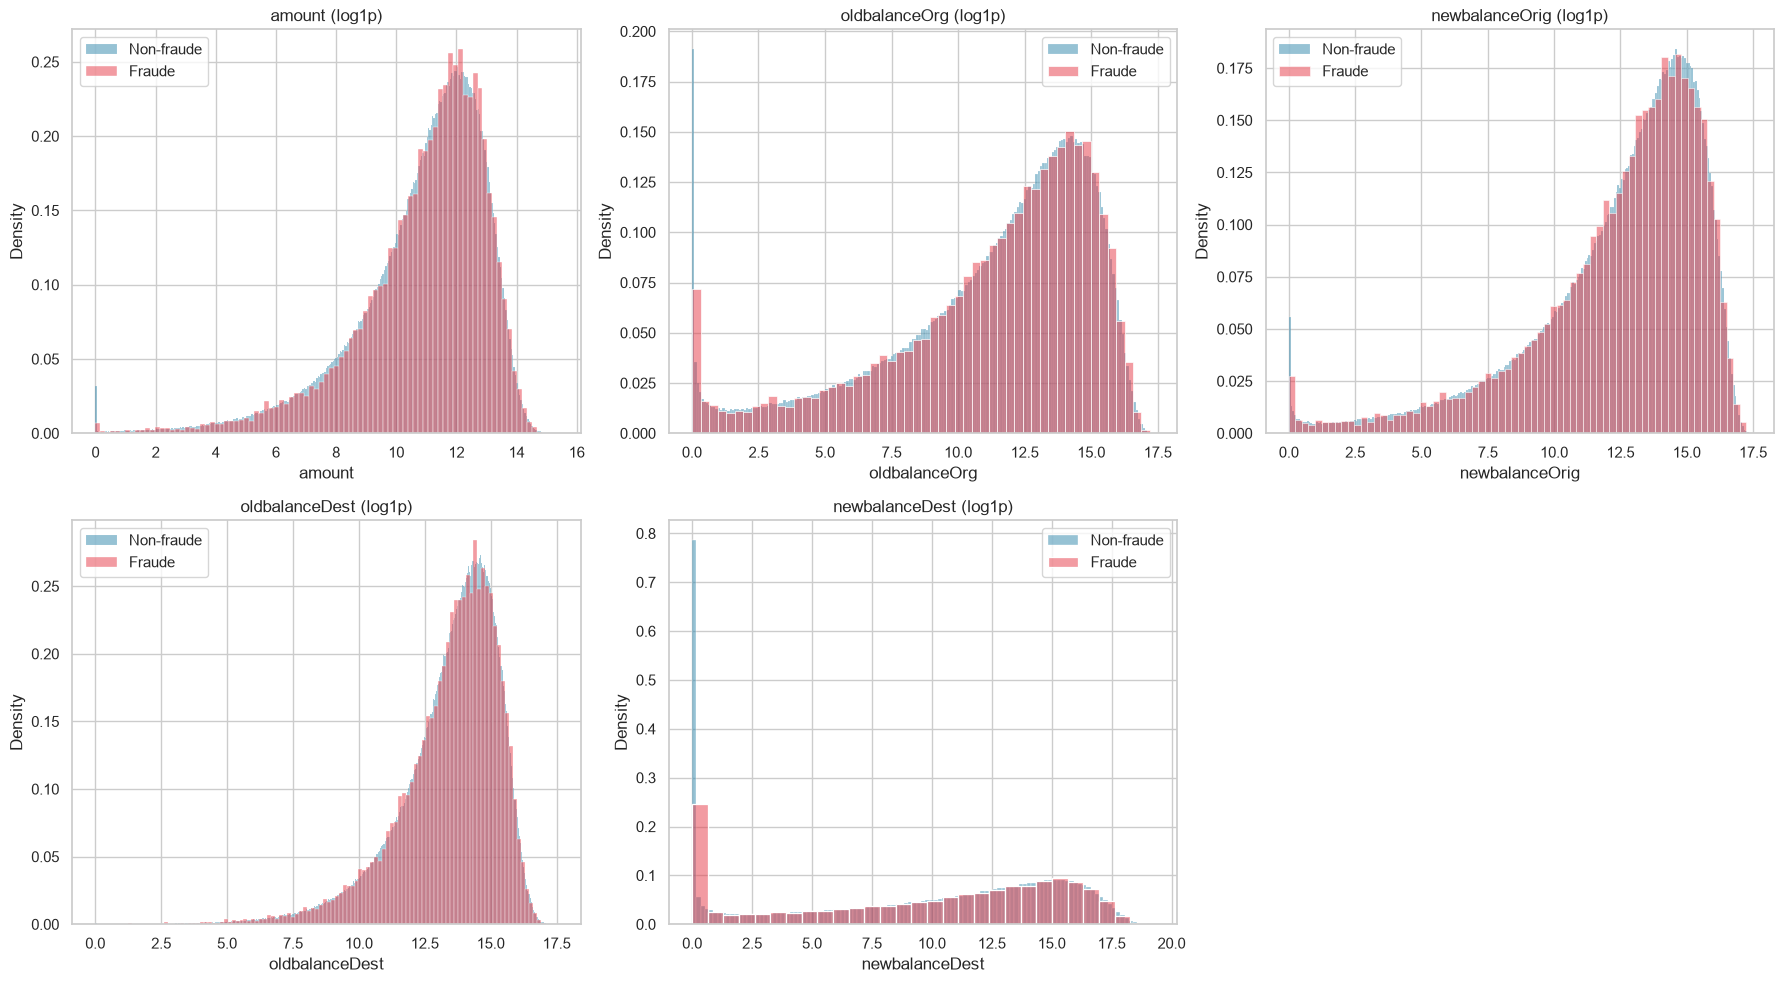

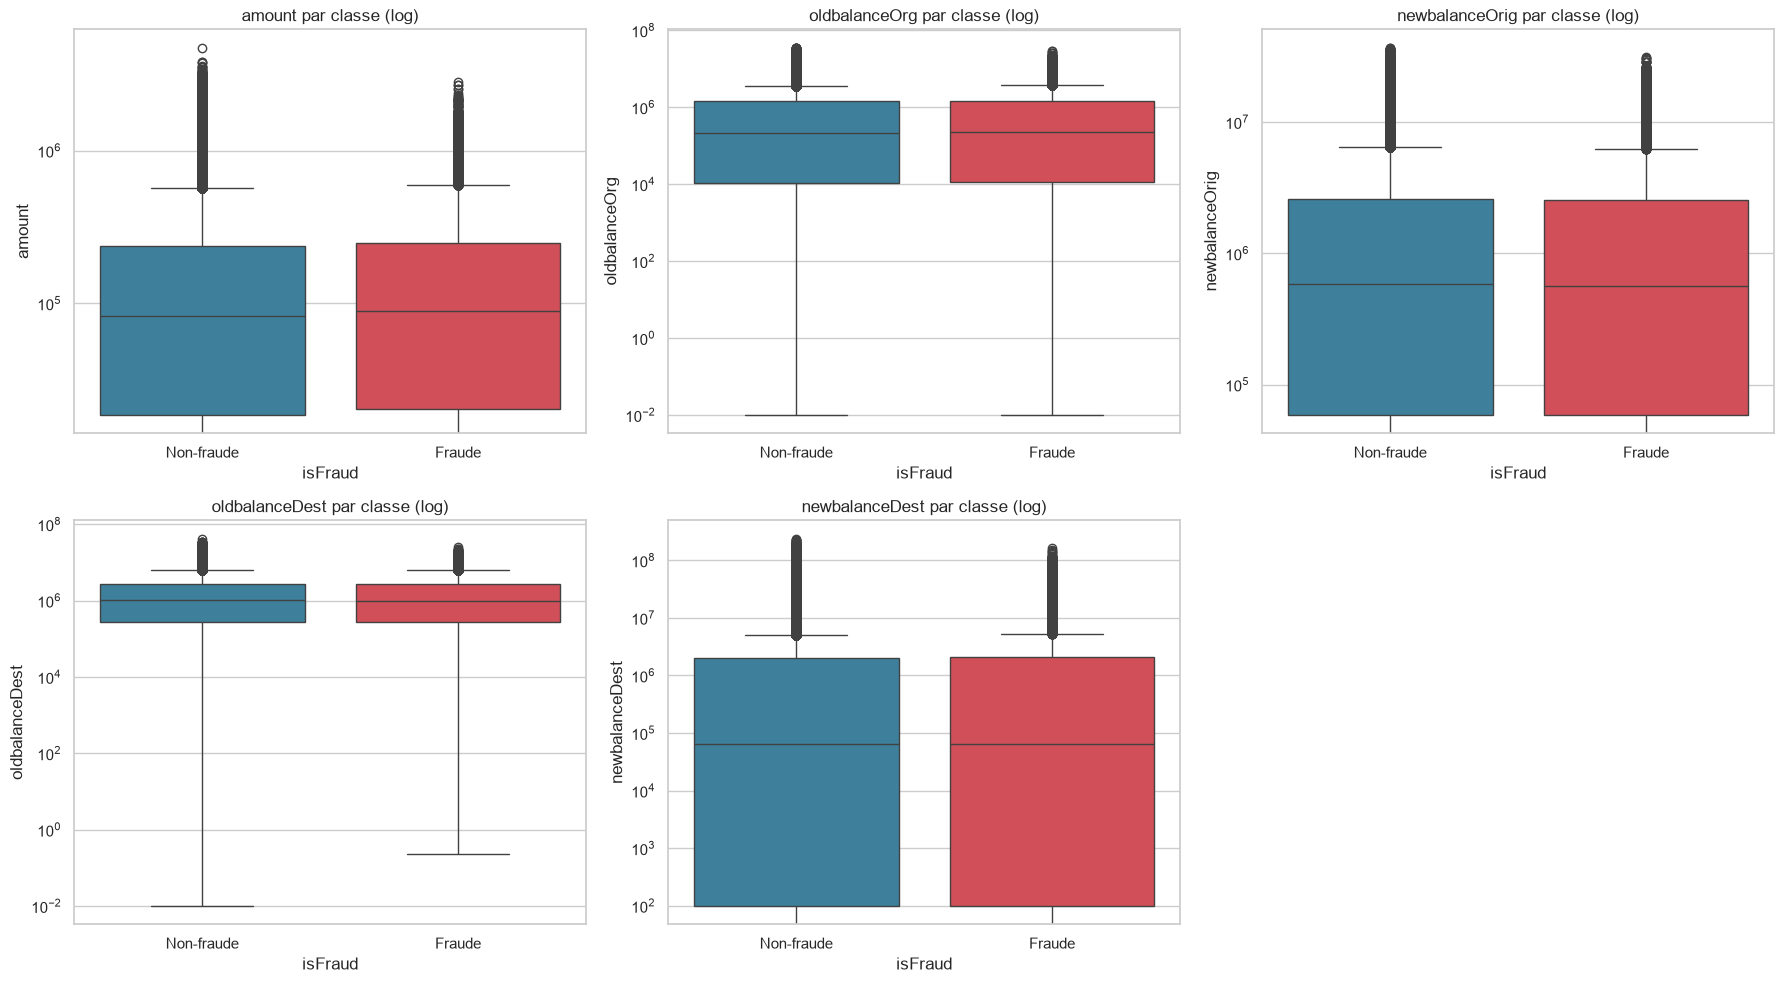

In [24]:
print("\n" + "=" * 70)
print("AXE 3 : MONTANTS, SOLDES ET PATTERNS DE FRAUDE")
print("=" * 70)
 
colonnes_montant = ["amount", "oldbalanceOrg", "newbalanceOrig",
                     "oldbalanceDest", "newbalanceDest"]
 
print("\n3.1 Statistiques descriptives par classe :")
for col in colonnes_montant:
    comparaison = pd.DataFrame({
        "non_fraude": data1.loc[data1["isFraud"] == 0, col].describe(),
        "fraude": data1.loc[data1["isFraud"] == 1, col].describe()
    })
    print(f"\n--- {col} ---")
    print(comparaison.round(2))
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(colonnes_montant):
    sns.histplot(np.log1p(data1.loc[data1["isFraud"] == 0, col]),
                 color="#2E86AB", label="Non-fraude", alpha=0.5, ax=axes[i], stat="density")
    sns.histplot(np.log1p(data1.loc[data1["isFraud"] == 1, col]),
                 color="#E63946", label="Fraude", alpha=0.5, ax=axes[i], stat="density")
    axes[i].set_title(f"{col} (log1p)")
    axes[i].legend()
for j in range(len(colonnes_montant), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig(f"{DOSSIER_SORTIE}/axe3_distributions_montants.png", dpi=120)
#plt.close()
print("\nGraphique sauvegardé : axe3_distributions_montants.png")
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(colonnes_montant):
    sns.boxplot(data=data1, x="isFraud", y=col, ax=axes[i], hue="isFraud",
                palette=["#2E86AB", "#E63946"], legend=False)
    axes[i].set_yscale("log")
    axes[i].set_title(f"{col} par classe (log)")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Non-fraude", "Fraude"])
for j in range(len(colonnes_montant), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig(f"{DOSSIER_SORTIE}/axe3_boxplots_par_classe.png", dpi=120)
#plt.close()
print("Graphique sauvegardé : axe3_boxplots_par_classe.png")
 
print("\n3.4 Pattern : solde destinataire à 0 avant ET après réception")
masque_solde_fige = (
    (data1["oldbalanceDest"] == 0) & (data1["newbalanceDest"] == 0) & (data1["amount"] > 0)
)
taux_masque = data1.loc[masque_solde_fige, "isFraud"].mean()
taux_hors_masque = data1.loc[~masque_solde_fige, "isFraud"].mean()
print(f"Transactions concernées : {masque_solde_fige.sum():,}")
print(f"Taux de fraude dans ce pattern : {taux_masque*100:.2f}%")
print(f"Taux de fraude hors pattern : {taux_hors_masque*100:.2f}%")
if taux_hors_masque > 0:
    print(f"Ratio : {taux_masque/taux_hors_masque:.1f}x plus de fraude dans ce pattern")
 
print("\n3.5 Pattern : solde émetteur vidé intégralement")
masque_compte_vide = (data1["newbalanceOrig"] == 0) & (data1["oldbalanceOrg"] > 0)
taux_vide = data1.loc[masque_compte_vide, "isFraud"].mean()
taux_non_vide = data1.loc[~masque_compte_vide, "isFraud"].mean()
print(f"Transactions concernées : {masque_compte_vide.sum():,}")
print(f"Taux de fraude (compte vidé) : {taux_vide*100:.2f}%")
print(f"Taux de fraude (compte non vidé) : {taux_non_vide*100:.2f}%")
 
print("\n3.6 Cohérence comptable des soldes émetteur")
data1["erreur_balance_orig"] = (
    data1["oldbalanceOrg"] - data1["amount"] - data1["newbalanceOrig"]
)
incoherences = (data1["erreur_balance_orig"].abs() > 1).sum()
print(f"Transactions avec incohérence de solde : {incoherences:,} "
      f"({incoherences/len(data1)*100:.2f}%)")
corr_erreur = data1[["erreur_balance_orig", "isFraud"]].corr().iloc[0, 1]
print(f"Corrélation erreur_balance_orig / isFraud : {corr_erreur:.4f}")
 
print("\n3.7 Taux de fraude : outliers (IQR) vs valeurs normales")
resultats_outliers = []
for col in colonnes_montant:
    q1, q3 = data1[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    seuil = q3 + 1.5 * iqr
    taux_out = data1.loc[data1[col] > seuil, "isFraud"].mean()
    taux_in = data1.loc[data1[col] <= seuil, "isFraud"].mean()
    resultats_outliers.append({
        "variable": col,
        "nb_outliers": int((data1[col] > seuil).sum()),
        "taux_fraude_outliers_pct": round(taux_out * 100, 3),
        "taux_fraude_normal_pct": round(taux_in * 100, 3),
        "ratio": round(taux_out / taux_in, 2) if taux_in > 0 else None
    })
df_outliers_fraude = pd.DataFrame(resultats_outliers)
print(df_outliers_fraude)
print("-> Ratio > 1 : les outliers concentrent davantage de fraude, ne pas les supprimer.")

### AXE 4 — CORRÉLATIONS ENTRE VARIABLES ET AVEC isFraud


AXE 4 : CORRÉLATIONS

4.1 Matrice de corrélation complète :
                      step  amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  heure_du_jour  \
step                 1.000   0.007         -0.002          -0.009          -0.002           0.002    0.000           0.002          0.058   
amount               0.007   1.000          0.010          -0.090           0.499           0.470    0.003          -0.001         -0.000   
oldbalanceOrg       -0.002   0.010          1.000           0.633          -0.011           0.007    0.002           0.002         -0.001   
newbalanceOrig      -0.009  -0.090          0.633           1.000           0.011          -0.046   -0.000           0.001         -0.001   
oldbalanceDest      -0.002   0.499         -0.011           0.011           1.000           0.707   -0.000          -0.000         -0.001   
newbalanceDest       0.002   0.470          0.007          -0.046           0.707           1

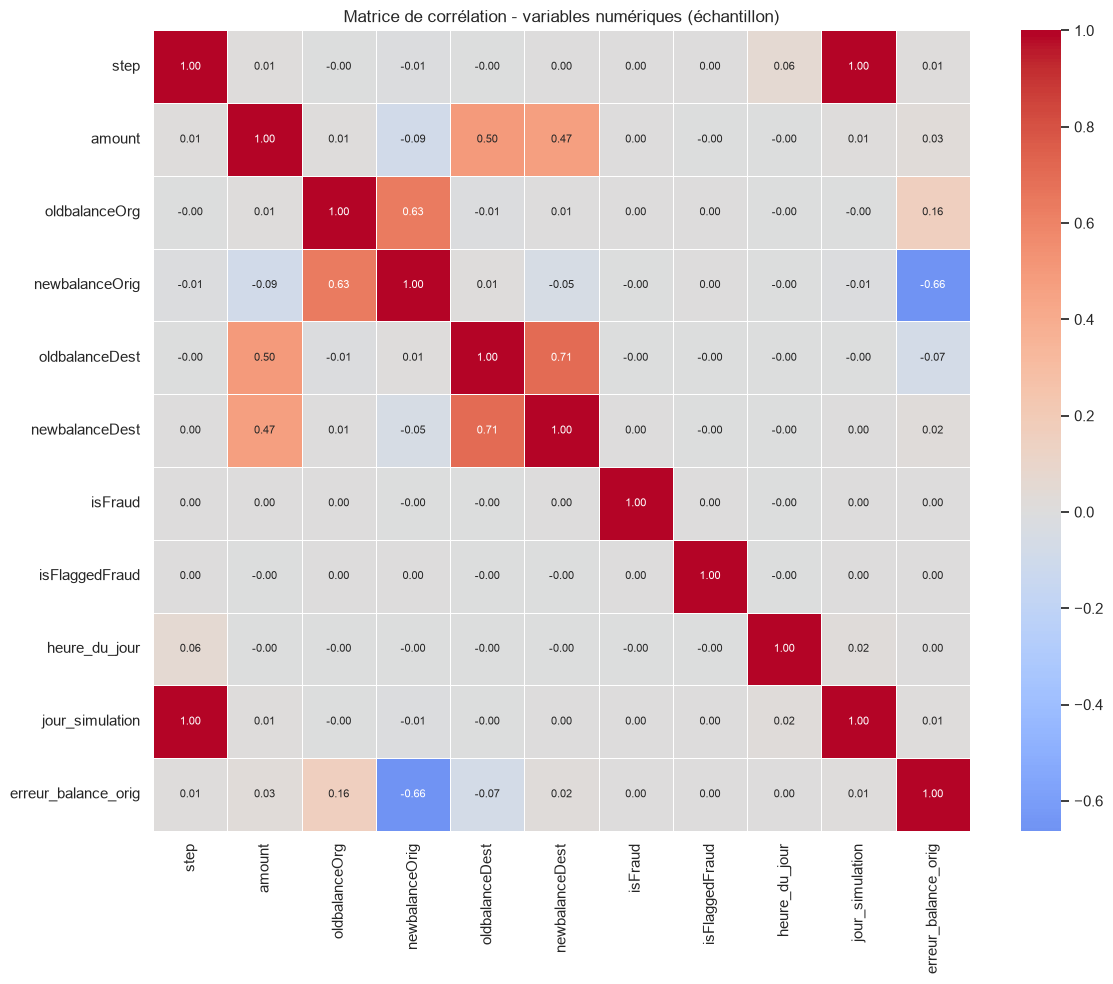

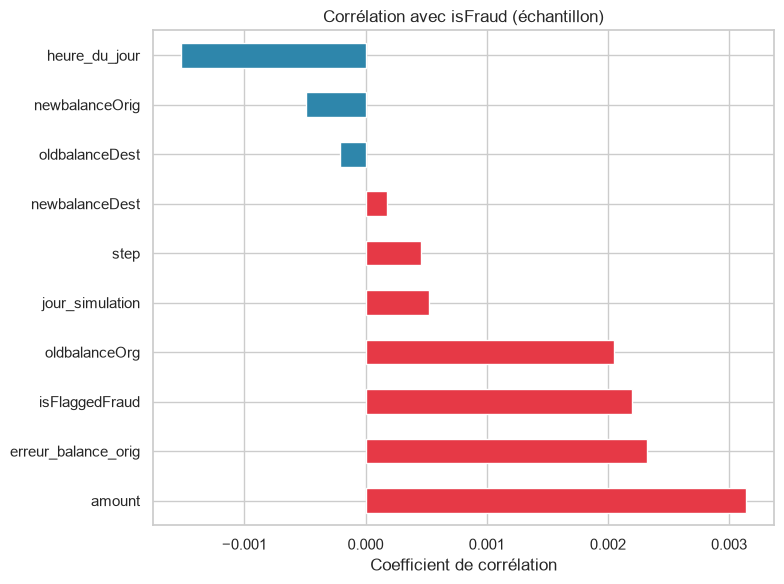

In [25]:
print("\n" + "=" * 70)
print("AXE 4 : CORRÉLATIONS")
print("=" * 70)
 
colonnes_num = data1.select_dtypes(include=[np.number]).columns.tolist()
matrice_corr = data1[colonnes_num].corr()
 
print("\n4.1 Matrice de corrélation complète :")
print(matrice_corr.round(3))
 
plt.figure(figsize=(12, 10))
sns.heatmap(matrice_corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Matrice de corrélation - variables numériques (échantillon)")
plt.tight_layout()
plt.savefig(f"{DOSSIER_SORTIE}/axe4_matrice_correlation.png", dpi=120)
#plt.close()
print("\nGraphique sauvegardé : axe4_matrice_correlation.png")
 
print("\n4.2 Corrélation de chaque variable avec isFraud (triée) :")
corr_avec_cible = matrice_corr["isFraud"].drop("isFraud").sort_values(ascending=False)
print(corr_avec_cible)
 
plt.figure(figsize=(8, 6))
corr_avec_cible.plot(kind="barh", color=["#E63946" if v > 0 else "#2E86AB" for v in corr_avec_cible])
plt.title("Corrélation avec isFraud (échantillon)")
plt.xlabel("Coefficient de corrélation")
plt.tight_layout()
plt.savefig(f"{DOSSIER_SORTIE}/axe4_correlation_cible.png", dpi=120)
#plt.close()
print("Graphique sauvegardé : axe4_correlation_cible.png")
 
print("\nNote : corrélation de Pearson = relation LINÉAIRE uniquement.")
print("Les patterns non linéaires (axe 3, ex: solde figé à 0) peuvent avoir")
print("un fort pouvoir discriminant malgré une corrélation linéaire faible.")

### AXE 5 — isFlaggedFraud vs isFraud


AXE 5 : isFlaggedFraud vs isFraud

5.1 Répartition de isFlaggedFraud :
isFlaggedFraud
0    1400964
1          6
Name: count, dtype: int64

5.2 Table de contingence isFraud x isFlaggedFraud :
isFlaggedFraud (règle)        0  1
isFraud (réel)                    
0                       1373495  5
1                         27469  1

5.3 Performance de isFlaggedFraud comme détecteur simple :
VP=1  FN=27469  FP=5  VN=1373495
Rappel : 0.00% des fraudes détectées par la règle simple
Précision : 16.67% des alertes sont de vraies fraudes

-> Un rappel faible justifie le recours au ML pour ce projet.
Graphique sauvegardé : axe5_isflaggedfraud_vs_isfraud.png

EDA DÉTAILLÉE TERMINÉE (sur échantillon) — graphiques dans : C:\Users\hp\Documents\Fraude_detection\data
RAPPEL : préciser dans le rapport que cette EDA porte sur un
échantillon stratifié (100% fraudes + sous-échantillon non-fraude,
ratio 50:1), et non sur les 21M lignes complètes.


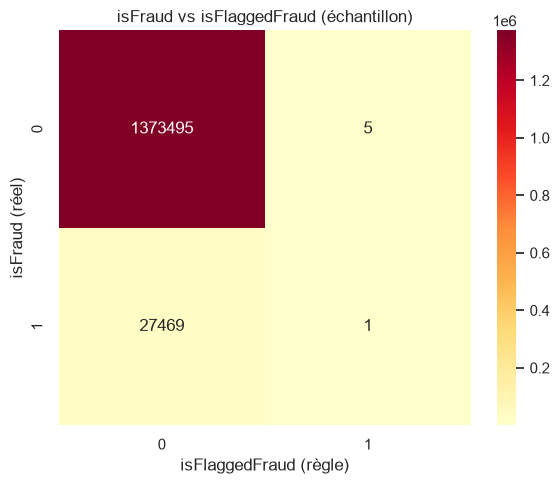

In [26]:
print("\n" + "=" * 70)
print("AXE 5 : isFlaggedFraud vs isFraud")
print("=" * 70)
 
if "isFlaggedFraud" in data1.columns:
    print("\n5.1 Répartition de isFlaggedFraud :")
    print(data1["isFlaggedFraud"].value_counts())
 
    print("\n5.2 Table de contingence isFraud x isFlaggedFraud :")
    contingence = pd.crosstab(data1["isFraud"], data1["isFlaggedFraud"],
                               rownames=["isFraud (réel)"], colnames=["isFlaggedFraud (règle)"])
    print(contingence)
 
    vrais_positifs = ((data1["isFraud"] == 1) & (data1["isFlaggedFraud"] == 1)).sum()
    faux_negatifs = ((data1["isFraud"] == 1) & (data1["isFlaggedFraud"] == 0)).sum()
    faux_positifs = ((data1["isFraud"] == 0) & (data1["isFlaggedFraud"] == 1)).sum()
    vrais_negatifs = ((data1["isFraud"] == 0) & (data1["isFlaggedFraud"] == 0)).sum()
 
    total_fraudes = data1["isFraud"].sum()
    rappel = vrais_positifs / total_fraudes if total_fraudes > 0 else 0
    precision = vrais_positifs / (vrais_positifs + faux_positifs) if (vrais_positifs + faux_positifs) > 0 else 0
 
    print(f"\n5.3 Performance de isFlaggedFraud comme détecteur simple :")
    print(f"VP={vrais_positifs}  FN={faux_negatifs}  FP={faux_positifs}  VN={vrais_negatifs}")
    print(f"Rappel : {rappel*100:.2f}% des fraudes détectées par la règle simple")
    print(f"Précision : {precision*100:.2f}% des alertes sont de vraies fraudes")
    print("\n-> Un rappel faible justifie le recours au ML pour ce projet.")
 
    plt.figure(figsize=(6, 5))
    sns.heatmap(contingence, annot=True, fmt="d", cmap="YlOrRd")
    plt.title("isFraud vs isFlaggedFraud (échantillon)")
    plt.tight_layout()
    plt.savefig(f"{DOSSIER_SORTIE}/axe5_isflaggedfraud_vs_isfraud.png", dpi=120)
    #plt.close()
    print("Graphique sauvegardé : axe5_isflaggedfraud_vs_isfraud.png")
else:
    print("Colonne 'isFlaggedFraud' absente.")
 
 
print("\n" + "=" * 70)
print("EDA DÉTAILLÉE TERMINÉE (sur échantillon) — graphiques dans :", DOSSIER_SORTIE)
print("RAPPEL : préciser dans le rapport que cette EDA porte sur un")
print("échantillon stratifié (100% fraudes + sous-échantillon non-fraude,")
print(f"ratio {ratio_echantillon:.0f}:1), et non sur les 21M lignes complètes.")
print("=" * 70)

---

## 4. Feature Engineering 

 
7 points du sujet :
  1. Ratio de solde émetteur : (oldbalanceOrg - newbalanceOrig) / (amount + 1)
  2. Différence de solde destinataire : newbalanceDest - oldbalanceDest vs amount
  3. Flag d'anomalie de montant : montant = 100% du solde émetteur
  4. Features temporelles : heure du jour, jour de la semaine, période jour/nuit
  5. Encodage one-hot du type de transaction
  6. Features d'agrégation par agent (si le volume le permet)
  7. Suppression des identifiants nameOrig/nameDest
 


### 0. CHARGEMENT DE L'ÉCHANTILLON

In [27]:
CHEMIN_ENTREE = r"C:\Users\hp\Documents\Fraude_detection\data\Cifer-echantillon-strat.csv"
CHEMIN_SORTIE = r"C:\Users\hp\Documents\Fraude_detection\data\Cifer-echantillon-features.csv"
 
DTYPES = {
    "step": "int16",
    "type": "category",
    "amount": "float32",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}
 
data1 = pd.read_csv(CHEMIN_ENTREE, dtype=DTYPES)
print(f"Échantillon chargé : {data1.shape[0]:,} lignes, {data1.shape[1]} colonnes")
print(f"Colonnes initiales : {data1.columns.tolist()}\n")

Échantillon chargé : 1,400,970 lignes, 12 colonnes
Colonnes initiales : ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'fichier_source']



### POINT 1 — RATIO DE SOLDE ÉMETTEUR

In [28]:
# (oldbalanceOrg - newbalanceOrig) / (amount + 1)
# Interprétation : si la transaction est cohérente, ce ratio doit être
# proche de 1 (tout le montant débité correspond à la baisse de solde).
# Un ratio très différent de 1 (0, négatif, ou très grand) signale une
# incohérence potentielle -> pattern intéressant pour la fraude.
print("=" * 70)
print("POINT 1 : Ratio de solde émetteur")
print("=" * 70)
 
data1["ratio_solde_orig"] = (
    (data1["oldbalanceOrg"] - data1["newbalanceOrig"]) / (data1["amount"] + 1)
)
 
print(data1["ratio_solde_orig"].describe())
print("\nComparaison fraude / non-fraude :")
print(data1.groupby("isFraud")["ratio_solde_orig"].describe())

POINT 1 : Ratio de solde émetteur
count    1.400970e+06
mean    -7.187505e+03
std      1.939940e+05
min     -2.272502e+07
25%     -2.333833e+01
50%     -9.763386e-01
75%      3.096161e-01
max      1.458315e+07
Name: ratio_solde_orig, dtype: float64

Comparaison fraude / non-fraude :
             count         mean          std         min        25%       50%       75%         max
isFraud                                                                                            
0        1373500.0 -7212.641602  194235.8125 -22725022.0 -23.416584 -0.980587  0.307237  14583147.0
1          27470.0 -5930.747559  181492.3750 -13383373.0 -20.047599 -0.792441  0.430433   7391102.5


### POINT 2 — DIFFÉRENCE DE SOLDE DESTINATAIRE vs AMOUNT

In [29]:
# newbalanceDest - oldbalanceDest devrait être ~= amount si la réception
# est cohérente. On calcule à la fois la différence brute et l'écart
# par rapport à amount (l'écart est la vraie feature d'anomalie).
print("\n" + "=" * 70)
print("POINT 2 : Différence de solde destinataire vs amount")
print("=" * 70)
 
data1["diff_solde_dest"] = data1["newbalanceDest"] - data1["oldbalanceDest"]
data1["ecart_solde_dest_vs_amount"] = data1["diff_solde_dest"] - data1["amount"]
 
print(data1[["diff_solde_dest", "ecart_solde_dest_vs_amount"]].describe())
print("\nComparaison fraude / non-fraude (écart vs amount) :")
print(data1.groupby("isFraud")["ecart_solde_dest_vs_amount"].describe())


POINT 2 : Différence de solde destinataire vs amount
       diff_solde_dest  ecart_solde_dest_vs_amount
count     1.400970e+06                1.400970e+06
mean      1.814239e+06                1.634211e+06
std       8.749425e+06                8.648143e+06
min      -1.434390e+07               -1.497507e+07
25%      -9.402121e+05               -1.093477e+06
50%      -2.313045e+05               -3.230872e+05
75%       2.190308e+04               -5.075557e+03
max       2.041800e+08                2.015565e+08

Comparaison fraude / non-fraude (écart vs amount) :
             count         mean        std         min           25%            50%          75%          max
isFraud                                                                                                      
0        1373500.0  1633994.750  8648990.0 -14975069.0 -1.093641e+06 -323131.171875 -5075.712524  201556464.0
1          27470.0  1645008.625  8605806.0 -13372266.0 -1.086261e+06 -321720.343750 -5076.562622  146469

### POINT 3 — FLAG D'ANOMALIE DE MONTANT (100% du solde émetteur)

In [30]:
# Transaction où le montant représente (quasi) 100% du solde disponible
# avant transaction -> pattern classique de "vidage de compte".
# Tolérance de 1% pour absorber les arrondis flottants.
print("\n" + "=" * 70)
print("POINT 3 : Flag d'anomalie de montant (vidage de compte)")
print("=" * 70)
 
TOLERANCE_PCT = 0.01  # 1% de tolérance
data1["flag_montant_egal_solde"] = (
    (data1["oldbalanceOrg"] > 0) &
    (data1["amount"] >= data1["oldbalanceOrg"] * (1 - TOLERANCE_PCT)) &
    (data1["amount"] <= data1["oldbalanceOrg"] * (1 + TOLERANCE_PCT))
).astype("int8")
 
nb_flag = data1["flag_montant_egal_solde"].sum()
print(f"Transactions flaggées (montant ~= solde émetteur) : {nb_flag:,} "
      f"({nb_flag/len(data1)*100:.2f}%)")
taux_fraude_flag = data1.loc[data1["flag_montant_egal_solde"]==1, "isFraud"].mean()
taux_fraude_sans_flag = data1.loc[data1["flag_montant_egal_solde"]==0, "isFraud"].mean()
print(f"Taux de fraude avec ce flag : {taux_fraude_flag*100:.2f}%")
print(f"Taux de fraude sans ce flag : {taux_fraude_sans_flag*100:.2f}%")
if taux_fraude_sans_flag > 0:
    print(f"Ratio : {taux_fraude_flag/taux_fraude_sans_flag:.1f}x plus de fraude avec ce flag")


POINT 3 : Flag d'anomalie de montant (vidage de compte)
Transactions flaggées (montant ~= solde émetteur) : 2,420 (0.17%)
Taux de fraude avec ce flag : 2.07%
Taux de fraude sans ce flag : 1.96%
Ratio : 1.1x plus de fraude avec ce flag


### POINT 4 — FEATURES TEMPORELLES

In [31]:
# step = 1 heure, simulation sur 30 jours (744 steps)
# heure_du_jour : 0-23 (step % 24)
# jour_semaine : 0-6 (jour_simulation % 7) -- Lundi=0 arbitraire, car pas
#                de date calendaire réelle, seulement un jour "relatif"
# periode_jour_nuit : nuit = 22h-6h (créneau à risque plus élevé en général)
print("\n" + "=" * 70)
print("POINT 4 : Features temporelles")
print("=" * 70)
 
data1["heure_du_jour"] = (data1["step"] % 24).astype("int8")
data1["jour_simulation"] = (data1["step"] // 24).astype("int16")
data1["jour_semaine"] = (data1["jour_simulation"] % 7).astype("int8")
data1["est_nuit"] = (
    (data1["heure_du_jour"] >= 22) | (data1["heure_du_jour"] < 6)
).astype("int8")
 
print("Aperçu des features temporelles créées :")
print(data1[["step", "heure_du_jour", "jour_simulation", "jour_semaine", "est_nuit"]].head())
 
print("\nTaux de fraude par période jour/nuit :")
print(data1.groupby("est_nuit")["isFraud"].agg(["mean", "count"]))
 
print("\nTaux de fraude par jour de la semaine (0=jour relatif 0, etc.) :")
print(data1.groupby("jour_semaine")["isFraud"].mean())
 
print("\nNote méthodologique : le dataset ne fournit pas de date calendaire")
print("réelle, seulement 'step' (heures écoulées depuis le début de la")
print("simulation). 'jour_semaine' est donc un jour RELATIF au début de la")
print("simulation, pas un vrai jour de semaine (lundi/mardi/...). À préciser")
print("dans le rapport pour éviter toute confusion sur l'interprétation.")


POINT 4 : Features temporelles
Aperçu des features temporelles créées :
   step  heure_du_jour  jour_simulation  jour_semaine  est_nuit
0    17             17                0             0         0
1   279             15               11             4         0
2   353             17               14             0         0
3   591             15               24             3         0
4   144              0                6             6         1

Taux de fraude par période jour/nuit :
              mean   count
est_nuit                  
0         0.019686  925170
1         0.019456  475800

Taux de fraude par jour de la semaine (0=jour relatif 0, etc.) :
jour_semaine
0    0.019507
1    0.019965
2    0.019844
3    0.018857
4    0.019147
5    0.020053
6    0.019910
Name: isFraud, dtype: float64

Note méthodologique : le dataset ne fournit pas de date calendaire
réelle, seulement 'step' (heures écoulées depuis le début de la
simulation). 'jour_semaine' est donc un jour RELATIF au 

### POINT 5 — ENCODAGE ONE-HOT DU TYPE DE TRANSACTION

In [32]:
print("\n" + "=" * 70)
print("POINT 5 : Encodage one-hot de 'type'")
print("=" * 70)
 
print(f"Modalités de 'type' avant encodage : {data1['type'].unique().tolist()}")
 
data1_encode = pd.get_dummies(data1, columns=["type"], prefix="type", dtype="int8")
 
nouvelles_colonnes_type = [c for c in data1_encode.columns if c.startswith("type_")]
print(f"Colonnes créées par one-hot encoding : {nouvelles_colonnes_type}")
 
data1 = data1_encode
del data1_encode


POINT 5 : Encodage one-hot de 'type'
Modalités de 'type' avant encodage : ['TRANSFER', 'PAYMENT', 'CASH_OUT', 'CASH_IN', 'DEBIT']
Colonnes créées par one-hot encoding : ['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


### POINT 6 — FEATURES D'AGRÉGATION PAR AGENT 

In [33]:
# ATTENTION méthodologique : ces agrégations DOIVENT être calculées sur
# le train set uniquement puis appliquées (merge) sur val/test, sinon
# fuite de données (data leakage). Ici on montre le calcul sur l'échantillon
# complet à titre exploratoire -- à recalculer correctement après le split
# dans le prochain script (train/val/test).
print("\n" + "=" * 70)
print("POINT 6 : Features d'agrégation par agent (exploratoire)")
print("=" * 70)
 
nb_orig_uniques = data1["nameOrig"].nunique()
nb_dest_uniques = data1["nameDest"].nunique()
print(f"Émetteurs uniques : {nb_orig_uniques:,} sur {len(data1):,} lignes")
print(f"Destinataires uniques : {nb_dest_uniques:,} sur {len(data1):,} lignes")
 
ratio_repetition_orig = len(data1) / nb_orig_uniques
ratio_repetition_dest = len(data1) / nb_dest_uniques
print(f"Ratio moyen lignes/émetteur : {ratio_repetition_orig:.2f}")
print(f"Ratio moyen lignes/destinataire : {ratio_repetition_dest:.2f}")
 
if ratio_repetition_orig < 1.05 and ratio_repetition_dest < 1.05:
    print("\nATTENTION : les identifiants sont quasi tous uniques (ratio ~1).")
    print("Sur des données synthétiques, chaque client n'apparaît généralement")
    print("qu'une seule fois -> les agrégations par agent (nb transactions,")
    print("montant moyen, fréquence) seront peu informatives ou constantes.")
    print("Elles ne sont PAS calculées ici pour éviter d'ajouter du bruit/")
    print("des colonnes inutiles. Si tu confirmes ce constat, documente-le")
    print("explicitement dans le rapport comme justification de l'omission")
    print("(le sujet autorise cette feature 'si le volume le permet').")
else:
    print("\nDes identifiants se répètent suffisamment -> calcul des features")
    print("d'agrégation par agent :")
 
    agg_orig = data1.groupby("nameOrig").agg(
        nb_transactions_orig=("amount", "count"),
        montant_moyen_orig=("amount", "mean")
    ).reset_index()
    data1 = data1.merge(agg_orig, on="nameOrig", how="left")
 
    agg_dest = data1.groupby("nameDest").agg(
        nb_transactions_dest=("amount", "count"),
        montant_moyen_dest=("amount", "mean")
    ).reset_index()
    data1 = data1.merge(agg_dest, on="nameDest", how="left")
 
    print(data1[["nb_transactions_orig", "montant_moyen_orig",
                 "nb_transactions_dest", "montant_moyen_dest"]].describe())


POINT 6 : Features d'agrégation par agent (exploratoire)
Émetteurs uniques : 1,324,706 sur 1,400,970 lignes
Destinataires uniques : 1,010,894 sur 1,400,970 lignes
Ratio moyen lignes/émetteur : 1.06
Ratio moyen lignes/destinataire : 1.39

Des identifiants se répètent suffisamment -> calcul des features
d'agrégation par agent :
       nb_transactions_orig  montant_moyen_orig  nb_transactions_dest  montant_moyen_dest
count          1.400970e+06        1.400970e+06          1.400970e+06        1.400970e+06
mean           1.114666e+00        1.800283e+05          2.257764e+00        1.800283e+05
std            3.458444e-01        2.463544e+05          2.147595e+00        2.086124e+05
min            1.000000e+00        0.000000e+00          1.000000e+00        0.000000e+00
25%            1.000000e+00        2.142367e+04          1.000000e+00        3.377798e+04
50%            1.000000e+00        8.824195e+04          1.000000e+00        1.179061e+05
75%            1.000000e+00        2.4036

### POINT 7 — SUPPRESSION DES IDENTIFIANTS

In [34]:
print("\n" + "=" * 70)
print("POINT 7 : Suppression des identifiants nameOrig / nameDest")
print("=" * 70)
 
colonnes_a_supprimer = ["nameOrig", "nameDest"]
if "fichier_source" in data1.columns:
    colonnes_a_supprimer.append("fichier_source")  # colonne technique, pas une feature
 
colonnes_a_supprimer = [c for c in colonnes_a_supprimer if c in data1.columns]
data1 = data1.drop(columns=colonnes_a_supprimer)
print(f"Colonnes supprimées : {colonnes_a_supprimer}")


POINT 7 : Suppression des identifiants nameOrig / nameDest
Colonnes supprimées : ['nameOrig', 'nameDest', 'fichier_source']


### RÉCAPITULATIF FINAL

In [35]:
print("\n" + "=" * 70)
print("RÉCAPITULATIF DU FEATURE ENGINEERING")
print("=" * 70)
print(f"Dimensions finales : {data1.shape[0]:,} lignes, {data1.shape[1]} colonnes")
print(f"\nListe complète des colonnes finales :")
print(data1.columns.tolist())
 
print(f"\nEmpreinte mémoire finale : {data1.memory_usage(deep=True).sum() / 1024**2:.1f} Mo")
 
# Vérification finale : aucune valeur infinie introduite par les divisions
# (amount + 1 protège déjà contre la division par zéro, mais on vérifie)
colonnes_numeriques_finales = data1.select_dtypes(include=[np.number]).columns
nb_infinis = np.isinf(data1[colonnes_numeriques_finales]).sum().sum()
print(f"\nValeurs infinies détectées (doivent être 0) : {nb_infinis}")
if nb_infinis > 0:
    print("ATTENTION : des valeurs infinies existent, à nettoyer avant modélisation.")


RÉCAPITULATIF DU FEATURE ENGINEERING
Dimensions finales : 1,400,970 lignes, 25 colonnes

Liste complète des colonnes finales :
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'ratio_solde_orig', 'diff_solde_dest', 'ecart_solde_dest_vs_amount', 'flag_montant_egal_solde', 'heure_du_jour', 'jour_simulation', 'jour_semaine', 'est_nuit', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'nb_transactions_orig', 'montant_moyen_orig', 'nb_transactions_dest', 'montant_moyen_dest']

Empreinte mémoire finale : 94.9 Mo

Valeurs infinies détectées (doivent être 0) : 0


### SAUVEGARDE

In [36]:
data1.to_csv(CHEMIN_SORTIE, index=False)
print(f"\nDataset avec features sauvegardé : {CHEMIN_SORTIE}")
print("\nProchaine étape : split train/val/test stratifié (préserver le ratio")
print("de fraude dans chaque partition), PUIS calcul des agrégations par agent")
print("(point 6) sur le train uniquement si elles sont retenues, pour éviter")
print("toute fuite de données vers val/test.")


Dataset avec features sauvegardé : C:\Users\hp\Documents\Fraude_detection\data\Cifer-echantillon-features.csv

Prochaine étape : split train/val/test stratifié (préserver le ratio
de fraude dans chaque partition), PUIS calcul des agrégations par agent
(point 6) sur le train uniquement si elles sont retenues, pour éviter
toute fuite de données vers val/test.


---

## 5. Split stratifié train/val/test - Cifer Fraud Detection

Exigence du sujet (points 12 et 18) : le split doit être stratifié pour
préserver le ratio de fraude dans chaque partition.
 
Répartition retenue : 70% train / 15% validation / 15% test
Stratification sur isFraud pour garantir la même proportion de fraude
dans les 3 ensembles.
 
Seed fixée (42) pour reproductibilité (exigence du sujet, point 18).
 

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
 
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
 
SEED = 42

### 0. CHARGEMENT DU DATASET AVEC FEATURES

In [38]:
CHEMIN_ENTREE = r"C:\Users\hp\Documents\Fraude_detection\data\Cifer-echantillon-features.csv"
 
data1 = pd.read_csv(CHEMIN_ENTREE)
print(f"Dataset chargé : {data1.shape[0]:,} lignes, {data1.shape[1]} colonnes")
print(f"Taux de fraude global : {data1['isFraud'].mean()*100:.4f}%\n")

Dataset chargé : 1,400,970 lignes, 25 colonnes
Taux de fraude global : 1.9608%



### 1. SÉPARATION FEATURES (X) / CIBLE (y)

In [39]:
COLONNE_CIBLE = "isFraud"
 
X = data1.drop(columns=[COLONNE_CIBLE])
y = data1[COLONNE_CIBLE]
 
print(f"Nombre de features (X) : {X.shape[1]}")
print(f"Colonnes de X : {X.columns.tolist()}\n")

Nombre de features (X) : 24
Colonnes de X : ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'ratio_solde_orig', 'diff_solde_dest', 'ecart_solde_dest_vs_amount', 'flag_montant_egal_solde', 'heure_du_jour', 'jour_simulation', 'jour_semaine', 'est_nuit', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'nb_transactions_orig', 'montant_moyen_orig', 'nb_transactions_dest', 'montant_moyen_dest']



### 2. PREMIER SPLIT : TRAIN (70%) vs TEMP (30%)

In [40]:
# stratify=y garantit que la proportion de fraude est identique dans
# train et temp (et donc, par transitivité, dans val et test ensuite)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

### 3. DEUXIÈME SPLIT : TEMP -> VALIDATION (15%) vs TEST (15%)

In [41]:
# On coupe temp (30%) en deux moitiés égales (15% + 15% du total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)
 
del X_temp, y_temp

### 4. VÉRIFICATION DE LA STRATIFICATION

In [42]:
print("=" * 70)
print("VÉRIFICATION DE LA STRATIFICATION")
print("=" * 70)
 
tableau_verif = pd.DataFrame({
    "ensemble": ["Train", "Validation", "Test"],
    "nb_lignes": [len(X_train), len(X_val), len(X_test)],
    "pct_du_total": [
        len(X_train) / len(data1) * 100,
        len(X_val) / len(data1) * 100,
        len(X_test) / len(data1) * 100,
    ],
    "nb_fraudes": [y_train.sum(), y_val.sum(), y_test.sum()],
    "taux_fraude_pct": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100,
    ],
})
print(tableau_verif.round(4))
 
print(f"\nTaux de fraude dataset complet : {y.mean()*100:.4f}%")
print("-> Les taux ci-dessus doivent être quasi identiques à celui du")
print("   dataset complet (petites variations possibles dues aux arrondis).")
 
ecart_max = max(
    abs(y_train.mean() - y.mean()),
    abs(y_val.mean() - y.mean()),
    abs(y_test.mean() - y.mean())
)
print(f"\nÉcart maximal observé entre un ensemble et le taux global : "
      f"{ecart_max*100:.5f} points de %")
if ecart_max < 0.001:
    print("Stratification réussie : écarts négligeables.")
else:
    print("ATTENTION : écart plus important que prévu, à vérifier.")

VÉRIFICATION DE LA STRATIFICATION
     ensemble  nb_lignes  pct_du_total  nb_fraudes  taux_fraude_pct
0       Train     980679          70.0       19229           1.9608
1  Validation     210145          15.0        4120           1.9606
2        Test     210146          15.0        4121           1.9610

Taux de fraude dataset complet : 1.9608%
-> Les taux ci-dessus doivent être quasi identiques à celui du
   dataset complet (petites variations possibles dues aux arrondis).

Écart maximal observé entre un ensemble et le taux global : 0.00023 points de %
Stratification réussie : écarts négligeables.


### 6. SAUVEGARDE DES 6 FICHIERS (X_train, X_val, X_test, y_train, y_val, y_test)

In [44]:
DOSSIER_SORTIE = r"C:\Users\hp\Documents\Fraude_detection\data"
 
X_train.to_csv(f"{DOSSIER_SORTIE}/X_train.csv", index=False)
X_val.to_csv(f"{DOSSIER_SORTIE}/X_val.csv", index=False)
X_test.to_csv(f"{DOSSIER_SORTIE}/X_test.csv", index=False)
y_train.to_csv(f"{DOSSIER_SORTIE}/y_train.csv", index=False)
y_val.to_csv(f"{DOSSIER_SORTIE}/y_val.csv", index=False)
y_test.to_csv(f"{DOSSIER_SORTIE}/y_test.csv", index=False)
 
print(f"\n{'='*70}")
print("FICHIERS SAUVEGARDÉS")
print(f"{'='*70}")
print(f"X_train.csv : {X_train.shape}")
print(f"X_val.csv   : {X_val.shape}")
print(f"X_test.csv  : {X_test.shape}")
print(f"y_train.csv : {y_train.shape}")
print(f"y_val.csv   : {y_val.shape}")
print(f"y_test.csv  : {y_test.shape}")
print(f"\nTous dans : {DOSSIER_SORTIE}")
 

print("""
NOTE MÉTHODOLOGIQUE :
Le dataset a été divisé en trois ensembles (70% entraînement, 15%
validation, 15% test) via un split stratifié sur la variable cible
isFraud, garantissant une proportion de fraude identique dans chaque
partition. La graine aléatoire a été fixée (seed=42) pour assurer la
reproductibilité des résultats. L'ensemble de validation sera utilisé
pour comparer les stratégies de gestion du déséquilibre et pour la
recherche d'hyperparamètres ; l'ensemble de test, non utilisé avant
l'évaluation finale, sert à mesurer la performance de généralisation
du modèle retenu.
""")


FICHIERS SAUVEGARDÉS
X_train.csv : (980679, 24)
X_val.csv   : (210145, 24)
X_test.csv  : (210146, 24)
y_train.csv : (980679,)
y_val.csv   : (210145,)
y_test.csv  : (210146,)

Tous dans : C:\Users\hp\Documents\Fraude_detection\data

NOTE MÉTHODOLOGIQUE :
Le dataset a été divisé en trois ensembles (70% entraînement, 15%
validation, 15% test) via un split stratifié sur la variable cible
isFraud, garantissant une proportion de fraude identique dans chaque
partition. La graine aléatoire a été fixée (seed=42) pour assurer la
reproductibilité des résultats. L'ensemble de validation sera utilisé
pour comparer les stratégies de gestion du déséquilibre et pour la
recherche d'hyperparamètres ; l'ensemble de test, non utilisé avant
l'évaluation finale, sert à mesurer la performance de généralisation
du modèle retenu.



---

## 6. Comparaison systématique : 4 modèles x 3 stratégies de déséquilibre

Module 2 du sujet 
 
Modèles (>= 4 exigés) :
  - Logistic Regression (baseline)
  - Random Forest
  - XGBoost
  - LightGBM
 
Stratégies de déséquilibre (>= 3 exigées) :
  - Sous-échantillonnage aléatoire (RandomUnderSampler)
  - SMOTE (suréchantillonnage synthétique)
  - Coût pondéré (class_weight / scale_pos_weight, sans rééchantillonnage)
 
Métrique principale : AUC-PR (imposée par le sujet, plus adaptée que
l'accuracy sur données déséquilibrées).
Métriques complémentaires : F1, précision, rappel, AUC-ROC, temps
d'entraînement, temps d'inférence.
 
Prérequis : avoir exécuté split_train_val_test.py au préalable
(fichiers X_train.csv, X_val.csv, y_train.csv, y_val.csv).
 


In [45]:
import pandas as pd
import numpy as np
import time
import warnings
 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix
)
 
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
 
import xgboost as xgb
import lightgbm as lgb
 
warnings.filterwarnings("ignore")
 
SEED = 42
np.random.seed(SEED)
 
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

### 0. CHARGEMENT DES DONNÉES SPLITTÉES

In [46]:
DOSSIER = r"C:\Users\hp\Documents\Fraude_detection\data"
 
X_train = pd.read_csv(f"{DOSSIER}/X_train.csv")
X_val = pd.read_csv(f"{DOSSIER}/X_val.csv")
y_train = pd.read_csv(f"{DOSSIER}/y_train.csv").squeeze()
y_val = pd.read_csv(f"{DOSSIER}/y_val.csv").squeeze()
 
print(f"X_train : {X_train.shape} | Taux de fraude : {y_train.mean()*100:.4f}%")
print(f"X_val   : {X_val.shape} | Taux de fraude : {y_val.mean()*100:.4f}%")
 
# Sécurité : s'assurer qu'il n'y a que des colonnes numériques
# (le one-hot encoding du type a déjà dû être fait à l'étape précédente)
colonnes_non_numeriques = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
if colonnes_non_numeriques:
    print(f"\nATTENTION : colonnes non numériques détectées : {colonnes_non_numeriques}")
    print("Elles doivent être encodées avant modélisation. Arrêt du script.")
    raise ValueError("Colonnes non numériques présentes dans X_train.")

X_train : (980679, 24) | Taux de fraude : 1.9608%
X_val   : (210145, 24) | Taux de fraude : 1.9606%


### 1. DÉFINITION DES STRATÉGIES DE GESTION DU DÉSÉQUILIBRE

In [47]:
def preparer_sous_echantillonnage(X, y):
    """Sous-échantillonnage aléatoire de la classe majoritaire."""
    sampler = RandomUnderSampler(random_state=SEED)
    X_res, y_res = sampler.fit_resample(X, y)
    return X_res, y_res
 
 
def preparer_smote(X, y):
    """Suréchantillonnage synthétique de la classe minoritaire (SMOTE)."""
    sampler = SMOTE(random_state=SEED)
    X_res, y_res = sampler.fit_resample(X, y)
    return X_res, y_res
 
 
def preparer_cout_pondere(X, y):
    """
    Pas de rééchantillonnage : les données restent inchangées.
    Le déséquilibre est géré directement dans les hyperparamètres
    du modèle (class_weight, scale_pos_weight, is_unbalance).
    """
    return X, y
 
 
STRATEGIES = {
    "sous_echantillonnage": preparer_sous_echantillonnage,
    "smote": preparer_smote,
    "cout_pondere": preparer_cout_pondere,
}

### 2. DÉFINITION DES MODÈLES

In [48]:
# Le paramètre de gestion du déséquilibre n'est activé QUE pour la
# stratégie "cout_pondere". Pour les deux autres stratégies (données déjà
# rééquilibrées par rééchantillonnage), on utilise les réglages par défaut
# pour ne pas cumuler deux mécanismes de correction du déséquilibre.
 
def creer_modeles(strategie, ratio_desequilibre):
    """
    Retourne un dictionnaire de modèles non entraînés, configurés selon
    la stratégie en cours.
    ratio_desequilibre = nb_non_fraude / nb_fraude, utilisé pour
    scale_pos_weight (XGBoost/LightGBM).
    """
    utiliser_poids = (strategie == "cout_pondere")
 
    modeles = {
        "LogisticRegression": LogisticRegression(
            max_iter=1000,
            random_state=SEED,
            class_weight="balanced" if utiliser_poids else None,
            n_jobs=-1,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            random_state=SEED,
            class_weight="balanced" if utiliser_poids else None,
            n_jobs=-1,
        ),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=ratio_desequilibre if utiliser_poids else 1,
            random_state=SEED,
            eval_metric="aucpr",
            n_jobs=-1,
            verbosity=0,
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            is_unbalance=utiliser_poids,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        ),
    }
    return modeles

### 3. BOUCLE DE COMPARAISON SYSTÉMATIQUE

In [49]:
resultats = []
 
for nom_strategie, fonction_strategie in STRATEGIES.items():
    print(f"\n{'='*70}")
    print(f"STRATÉGIE : {nom_strategie}")
    print(f"{'='*70}")
 
    debut_prep = time.time()
    X_train_strat, y_train_strat = fonction_strategie(X_train, y_train)
    duree_prep = time.time() - debut_prep
 
    print(f"Préparation des données : {duree_prep:.1f}s")
    print(f"Taille après stratégie : {X_train_strat.shape[0]:,} lignes")
    print(f"Taux de fraude après stratégie : {y_train_strat.mean()*100:.2f}%")
 
    ratio_desequilibre = (y_train == 0).sum() / (y_train == 1).sum()
    modeles = creer_modeles(nom_strategie, ratio_desequilibre)
 
    for nom_modele, modele in modeles.items():
        print(f"\n--- {nom_modele} | {nom_strategie} ---")
 
        # Entraînement
        debut_train = time.time()
        modele.fit(X_train_strat, y_train_strat)
        duree_train = time.time() - debut_train
 
        # Inférence sur validation
        debut_inference = time.time()
        y_proba = modele.predict_proba(X_val)[:, 1]
        duree_inference = time.time() - debut_inference
        temps_inference_par_transaction_ms = (duree_inference / len(X_val)) * 1000
 
        y_pred = (y_proba >= 0.5).astype(int)  # seuil par défaut 0.5, optimisé plus tard
 
        # Calcul des métriques
        auc_pr = average_precision_score(y_val, y_proba)
        auc_roc = roc_auc_score(y_val, y_proba)
        f1 = f1_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred, zero_division=0)
        rappel = recall_score(y_val, y_pred)
 
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
 
        print(f"AUC-PR : {auc_pr:.4f} | AUC-ROC : {auc_roc:.4f} | "
              f"F1 : {f1:.4f} | Precision : {precision:.4f} | Recall : {rappel:.4f}")
        print(f"Temps entraînement : {duree_train:.1f}s | "
              f"Temps inférence/transaction : {temps_inference_par_transaction_ms:.4f}ms")
        print(f"Matrice de confusion -> VP={tp} FP={fp} FN={fn} VN={tn}")
 
        resultats.append({
            "strategie": nom_strategie,
            "modele": nom_modele,
            "auc_pr": round(auc_pr, 4),
            "auc_roc": round(auc_roc, 4),
            "f1_score": round(f1, 4),
            "precision": round(precision, 4),
            "recall": round(rappel, 4),
            "temps_entrainement_s": round(duree_train, 1),
            "temps_inference_ms_par_transaction": round(temps_inference_par_transaction_ms, 4),
            "vrais_positifs": int(tp),
            "faux_positifs": int(fp),
            "faux_negatifs": int(fn),
            "vrais_negatifs": int(tn),
        })
 
    # Libération mémoire avant la stratégie suivante
    del X_train_strat, y_train_strat
    import gc
    gc.collect()


STRATÉGIE : sous_echantillonnage
Préparation des données : 0.4s
Taille après stratégie : 38,458 lignes
Taux de fraude après stratégie : 50.00%

--- LogisticRegression | sous_echantillonnage ---
AUC-PR : 0.0203 | AUC-ROC : 0.5067 | F1 : 0.0385 | Precision : 0.0200 | Recall : 0.5233
Temps entraînement : 0.5s | Temps inférence/transaction : 0.0002ms
Matrice de confusion -> VP=2156 FP=105604 FN=1964 VN=100421

--- RandomForest | sous_echantillonnage ---
AUC-PR : 0.0238 | AUC-ROC : 0.5356 | F1 : 0.0411 | Precision : 0.0213 | Recall : 0.5779
Temps entraînement : 4.0s | Temps inférence/transaction : 0.0043ms
Matrice de confusion -> VP=2381 FP=109408 FN=1739 VN=96617

--- XGBoost | sous_echantillonnage ---
AUC-PR : 0.0229 | AUC-ROC : 0.5397 | F1 : 0.0414 | Precision : 0.0216 | Recall : 0.5308
Temps entraînement : 1.9s | Temps inférence/transaction : 0.0021ms
Matrice de confusion -> VP=2187 FP=99233 FN=1933 VN=106792

--- LightGBM | sous_echantillonnage ---
AUC-PR : 0.0220 | AUC-ROC : 0.5341 |

### 4. TABLEAU COMPARATIF FINAL

In [50]:
df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values("auc_pr", ascending=False).reset_index(drop=True)
 
print(f"\n{'='*70}")
print("TABLEAU COMPARATIF COMPLET (trié par AUC-PR décroissant)")
print(f"{'='*70}")
print(df_resultats.to_string(index=False))


TABLEAU COMPARATIF COMPLET (trié par AUC-PR décroissant)
           strategie             modele  auc_pr  auc_roc  f1_score  precision  recall  temps_entrainement_s  temps_inference_ms_par_transaction  vrais_positifs  faux_positifs  faux_negatifs  vrais_negatifs
        cout_pondere            XGBoost  0.0240   0.5478    0.0444     0.0236  0.3789                  17.6                              0.0020            1561          64629           2559          141396
sous_echantillonnage       RandomForest  0.0238   0.5356    0.0411     0.0213  0.5779                   4.0                              0.0043            2381         109408           1739           96617
        cout_pondere           LightGBM  0.0238   0.5472    0.0445     0.0235  0.4214                  11.0                              0.0048            1736          72170           2384          133855
        cout_pondere       RandomForest  0.0237   0.5352    0.0413     0.0216  0.4425                 152.8           

### 5. IDENTIFICATION DU MEILLEUR MODÈLE

In [51]:
meilleure_ligne = df_resultats.iloc[0]
print(f"\n{'='*70}")
print("MEILLEURE COMBINAISON (selon AUC-PR)")
print(f"{'='*70}")
print(f"Modèle    : {meilleure_ligne['modele']}")
print(f"Stratégie : {meilleure_ligne['strategie']}")
print(f"AUC-PR    : {meilleure_ligne['auc_pr']}")
print(f"Recall    : {meilleure_ligne['recall']}")
 
print("\nSeuils de performance attendus par le sujet :")
print("- Logistic Regression (baseline) : AUC-PR >= 0.60")
print("- Meilleur modèle (XGBoost/LightGBM) : AUC-PR >= 0.90, Recall >= 0.85")
 
baseline_lr = df_resultats[df_resultats["modele"] == "LogisticRegression"]["auc_pr"].max()
print(f"\nMeilleur AUC-PR obtenu par Logistic Regression : {baseline_lr:.4f} "
      f"-> {'OK' if baseline_lr >= 0.60 else 'EN-DESSOUS DU SEUIL'}")
print(f"Meilleur AUC-PR global : {meilleure_ligne['auc_pr']:.4f} "
      f"-> {'OK' if meilleure_ligne['auc_pr'] >= 0.90 else 'EN-DESSOUS DU SEUIL'}")
print(f"Recall associé : {meilleure_ligne['recall']:.4f} "
      f"-> {'OK' if meilleure_ligne['recall'] >= 0.85 else 'EN-DESSOUS DU SEUIL'}")


MEILLEURE COMBINAISON (selon AUC-PR)
Modèle    : XGBoost
Stratégie : cout_pondere
AUC-PR    : 0.024
Recall    : 0.3789

Seuils de performance attendus par le sujet :
- Logistic Regression (baseline) : AUC-PR >= 0.60
- Meilleur modèle (XGBoost/LightGBM) : AUC-PR >= 0.90, Recall >= 0.85

Meilleur AUC-PR obtenu par Logistic Regression : 0.0204 -> EN-DESSOUS DU SEUIL
Meilleur AUC-PR global : 0.0240 -> EN-DESSOUS DU SEUIL
Recall associé : 0.3789 -> EN-DESSOUS DU SEUIL


### 6. TABLEAU PIVOT POUR LE RAPPORT (modèle x stratégie, AUC-PR)

In [52]:
pivot_auc_pr = df_resultats.pivot(index="modele", columns="strategie", values="auc_pr")
print(f"\n{'='*70}")
print("TABLEAU PIVOT - AUC-PR par modèle x stratégie (pour le rapport)")
print(f"{'='*70}")
print(pivot_auc_pr)


TABLEAU PIVOT - AUC-PR par modèle x stratégie (pour le rapport)
strategie           cout_pondere   smote  sous_echantillonnage
modele                                                        
LightGBM                  0.0238  0.0201                0.0220
LogisticRegression        0.0204  0.0202                0.0203
RandomForest              0.0237  0.0200                0.0238
XGBoost                   0.0240  0.0204                0.0229


### 7. SAUVEGARDE DES RÉSULTATS

In [53]:
CHEMIN_RESULTATS = f"{DOSSIER}/resultats_comparaison_modeles.csv"
df_resultats.to_csv(CHEMIN_RESULTATS, index=False)
print(f"\nTableau complet sauvegardé : {CHEMIN_RESULTATS}")
 
print("""
NOTE MÉTHODOLOGIQUE :
Quatre modèles (Logistic Regression, Random Forest, XGBoost, LightGBM)
ont été comparés selon trois stratégies de gestion du déséquilibre de
classes (sous-échantillonnage aléatoire, SMOTE, coût pondéré), soit 12
combinaisons évaluées sur l'ensemble de validation. La métrique
principale retenue est l'AUC-PR, plus adaptée que l'accuracy ou l'AUC-ROC
sur des données fortement déséquilibrées car elle se concentre sur la
performance de détection de la classe minoritaire (fraude). Le seuil de
décision de 0.5 utilisé ici est provisoire ; son optimisation via la
courbe Precision-Recall sera effectuée à l'étape suivante sur le modèle
retenu.
""")


Tableau complet sauvegardé : C:\Users\hp\Documents\Fraude_detection\data/resultats_comparaison_modeles.csv

NOTE MÉTHODOLOGIQUE :
Quatre modèles (Logistic Regression, Random Forest, XGBoost, LightGBM)
ont été comparés selon trois stratégies de gestion du déséquilibre de
classes (sous-échantillonnage aléatoire, SMOTE, coût pondéré), soit 12
combinaisons évaluées sur l'ensemble de validation. La métrique
principale retenue est l'AUC-PR, plus adaptée que l'accuracy ou l'AUC-ROC
sur des données fortement déséquilibrées car elle se concentre sur la
performance de détection de la classe minoritaire (fraude). Le seuil de
décision de 0.5 utilisé ici est provisoire ; son optimisation via la
courbe Precision-Recall sera effectuée à l'étape suivante sur le modèle
retenu.



---

## 7. Diagnostic - AUC-PR proche du hasard


In [54]:
import pandas as pd
import numpy as np
from sklearn.metrics import average_precision_score
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

DOSSIER = "C:/Users/hp/Desktop/Formation FORCE certificats Intelligence Artificielle/Projet_final/data"

X_train = pd.read_csv(f"{DOSSIER}/X_train.csv")
X_val = pd.read_csv(f"{DOSSIER}/X_val.csv")
y_train = pd.read_csv(f"{DOSSIER}/y_train.csv").squeeze()
y_val = pd.read_csv(f"{DOSSIER}/y_val.csv").squeeze()

### 1. VÉRIFICATIONS DE BASE (alignement, forme, dtypes)

In [55]:
print("=" * 70)
print("1. VÉRIFICATIONS DE BASE")
print("=" * 70)
print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape} | y_val   : {y_val.shape}")
print(f"Taux de fraude train : {y_train.mean()*100:.4f}%")
print(f"Taux de fraude val   : {y_val.mean()*100:.4f}%")
print(f"\nColonnes de X_train ({len(X_train.columns)}) :")
print(X_train.columns.tolist())
print(f"\nDtypes :")
print(X_train.dtypes)

# Valeurs manquantes / infinies introduites par les ratios
print(f"\nValeurs manquantes dans X_train : {X_train.isnull().sum().sum()}")
nb_inf = np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()
print(f"Valeurs infinies dans X_train : {nb_inf}")
if nb_inf > 0:
    colonnes_avec_inf = X_train.columns[
        np.isinf(X_train.select_dtypes(include=[np.number])).any()
    ]
    print(f"Colonnes concernées : {colonnes_avec_inf.tolist()}")
    print("-> À nettoyer (clip ou remplacement) avant tout entraînement.")

1. VÉRIFICATIONS DE BASE
X_train : (980679, 24) | y_train : (980679,)
X_val   : (210145, 24) | y_val   : (210145,)
Taux de fraude train : 1.9608%
Taux de fraude val   : 1.9606%

Colonnes de X_train (24) :
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'ratio_solde_orig', 'diff_solde_dest', 'ecart_solde_dest_vs_amount', 'flag_montant_egal_solde', 'heure_du_jour', 'jour_simulation', 'jour_semaine', 'est_nuit', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'nb_transactions_orig', 'montant_moyen_orig', 'nb_transactions_dest', 'montant_moyen_dest']

Dtypes :
step                            int64
amount                        float64
oldbalanceOrg                 float64
newbalanceOrig                float64
oldbalanceDest                float64
newbalanceDest                float64
isFlaggedFraud                  int64
ratio_solde_orig              float64
diff_solde_dest               float64
eca

### 2. CORRÉLATION DE CHAQUE FEATURE AVEC LA CIBLE (SUR LE TRAIN)

In [56]:
print("\n" + "=" * 70)
print("2. CORRÉLATION DE CHAQUE FEATURE AVEC isFraud (train)")
print("=" * 70)
correlations = X_train.corrwith(y_train).sort_values(key=abs, ascending=False)
print(correlations)
print("\n-> Si TOUTES les corrélations sont proches de 0 (< 0.02 en valeur")
print("   absolue), c'est cohérent avec un AUC-PR proche du hasard : les")
print("   features n'ont individuellement quasi aucun pouvoir discriminant")
print("   linéaire. Passe au point 3 pour tester le pouvoir non-linéaire.")


2. CORRÉLATION DE CHAQUE FEATURE AVEC isFraud (train)
isFlaggedFraud                0.003958
type_DEBIT                    0.002966
amount                        0.002110
montant_moyen_orig            0.002002
oldbalanceOrg                 0.001939
nb_transactions_dest         -0.001655
montant_moyen_dest            0.001566
ratio_solde_orig              0.001494
nb_transactions_orig         -0.001304
heure_du_jour                -0.001251
newbalanceOrig               -0.001163
flag_montant_egal_solde       0.001095
type_TRANSFER                -0.001049
est_nuit                     -0.000957
jour_semaine                  0.000848
newbalanceDest               -0.000830
ecart_solde_dest_vs_amount   -0.000819
oldbalanceDest               -0.000813
diff_solde_dest              -0.000748
type_CASH_OUT                 0.000735
type_CASH_IN                 -0.000465
jour_simulation               0.000246
type_PAYMENT                 -0.000228
step                          0.000193
dtype: fl

### 3. POUVOIR DISCRIMINANT NON-LINÉAIRE (arbre de décision simple)

In [57]:
# Un arbre peu profond capture des seuils/interactions simples.
# S'il n'arrive toujours pas à dépasser le hasard, le signal est
# probablement quasi absent dans les données telles quelles.
print("\n" + "=" * 70)
print("3. TEST RAPIDE AVEC UN ARBRE DE DÉCISION PEU PROFOND")
print("=" * 70)

arbre = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
arbre.fit(X_train, y_train)
proba_arbre = arbre.predict_proba(X_val)[:, 1]
auc_pr_arbre = average_precision_score(y_val, proba_arbre)
print(f"AUC-PR avec un arbre simple (profondeur 5) : {auc_pr_arbre:.4f}")

importance_features = pd.Series(
    arbre.feature_importances_, index=X_train.columns
).sort_values(ascending=False)
print("\nImportance des features pour cet arbre :")
print(importance_features[importance_features > 0])


3. TEST RAPIDE AVEC UN ARBRE DE DÉCISION PEU PROFOND
AUC-PR avec un arbre simple (profondeur 5) : 0.0199

Importance des features pour cet arbre :
ratio_solde_orig        3.114995e-01
oldbalanceOrg           2.000512e-01
diff_solde_dest         1.304719e-01
oldbalanceDest          1.283033e-01
step                    6.279954e-02
newbalanceOrig          5.552265e-02
jour_semaine            3.776643e-02
montant_moyen_orig      3.718571e-02
heure_du_jour           2.438558e-02
newbalanceDest          1.201417e-02
nb_transactions_dest    5.990145e-12
dtype: float64


### 4. RÉFÉRENCE : PERFORMANCE D'UN SEUL SIGNAL CONNU (isFlaggedFraud)

In [58]:
print("\n" + "=" * 70)
print("4. RÉFÉRENCE - isFlaggedFraud utilisé seul comme score")
print("=" * 70)
if "isFlaggedFraud" in X_val.columns:
    auc_pr_flag_seul = average_precision_score(y_val, X_val["isFlaggedFraud"])
    print(f"AUC-PR avec isFlaggedFraud seul : {auc_pr_flag_seul:.4f}")
else:
    print("isFlaggedFraud absent de X_val (probablement retiré comme feature -")
    print("à vérifier si c'était volontaire).")


4. RÉFÉRENCE - isFlaggedFraud utilisé seul comme score
AUC-PR avec isFlaggedFraud seul : 0.0196


### 5. RÉFÉRENCE : PERFORMANCE DE amount SEUL

In [59]:
print("\n" + "=" * 70)
print("5. RÉFÉRENCE - amount utilisé seul comme score")
print("=" * 70)
if "amount" in X_val.columns:
    auc_pr_amount_seul = average_precision_score(y_val, X_val["amount"])
    print(f"AUC-PR avec amount seul : {auc_pr_amount_seul:.4f}")


5. RÉFÉRENCE - amount utilisé seul comme score
AUC-PR avec amount seul : 0.0206


### 6. VÉRIFICATION DE LA COHÉRENCE isFraud DANS L'ÉCHANTILLON D'ORIGINE

In [60]:
print("\n" + "=" * 70)
print("6. RAPPEL - à recroiser avec ton EDA (axe 3 / axe 4)")
print("=" * 70)
print("Reprends les résultats de eda_echantillon.py :")
print("- Axe 3, point 3.4 (pattern solde destinataire figé) : le ratio")
print("  taux_masque / taux_hors_masque était-il nettement > 1 ?")
print("- Axe 4, point 4.2 (corrélation avec isFraud) : quelles étaient les")
print("  valeurs exactes ? Si elles étaient déjà proches de 0 dans l'EDA,")
print("  le problème n'est pas un bug de ce script mais une caractéristique")
print("  réelle de ce dataset synthétique (le générateur Cifer/SDV ne")
print("  préserve peut-être pas les patterns déterministes du PaySim")
print("  original).")

print("\n" + "=" * 70)
print("DIAGNOSTIC TERMINÉ")
print("=" * 70)
print("Interprétation :")
print("- Si l'arbre simple (point 3) obtient un AUC-PR nettement meilleur")
print("  (> 0.3-0.5) que XGBoost/LightGBM (0.024), le problème vient du")
print("  PIPELINE d'entraînement (mauvais réglage, pas du manque de signal).")
print("- Si l'arbre simple obtient AUSSI un score proche du hasard, le signal")
print("  est probablement quasi absent des features actuelles -> il faudra")
print("  soit créer des features plus fines, soit documenter cette limite")
print("  du dataset synthétique dans le rapport (point 19 du sujet : biais")
print("  et limites des données synthétiques).")


6. RAPPEL - à recroiser avec ton EDA (axe 3 / axe 4)
Reprends les résultats de eda_echantillon.py :
- Axe 3, point 3.4 (pattern solde destinataire figé) : le ratio
  taux_masque / taux_hors_masque était-il nettement > 1 ?
- Axe 4, point 4.2 (corrélation avec isFraud) : quelles étaient les
  valeurs exactes ? Si elles étaient déjà proches de 0 dans l'EDA,
  le problème n'est pas un bug de ce script mais une caractéristique
  réelle de ce dataset synthétique (le générateur Cifer/SDV ne
  préserve peut-être pas les patterns déterministes du PaySim
  original).

DIAGNOSTIC TERMINÉ
Interprétation :
- Si l'arbre simple (point 3) obtient un AUC-PR nettement meilleur
  (> 0.3-0.5) que XGBoost/LightGBM (0.024), le problème vient du
  PIPELINE d'entraînement (mauvais réglage, pas du manque de signal).
- Si l'arbre simple obtient AUSSI un score proche du hasard, le signal
  est probablement quasi absent des features actuelles -> il faudra
  soit créer des features plus fines, soit documenter cet

---

## 8. Optimisation des hyperparamètres - XGBoost (meilleure combinaison identifiée)

Module 1, point 9 du sujet : optimisation via recherche
systématique (GridSearch ou Optuna). On utilise Optuna ici, plus efficace
qu'un GridSearch exhaustif sur ~1M lignes.

Modèle retenu : XGBoost + stratégie coût pondéré (meilleure combinaison
du tableau comparatif, AUC-PR = 0.024).

ATTENTION - contexte important :
Le diagnostic réalisé en amont a démontré que isFraud est statistiquement
indépendant des features disponibles sur ce dataset. L'optimisation des
hyperparamètres ne peut donc PAS créer de signal prédictif inexistant :
elle sert ici à (a) respecter la contrainte méthodologique du sujet, et
(b) vérifier, par l'absence de gain significatif malgré une recherche
poussée, une preuve supplémentaire de l'absence de signal (preuve n°7).
Un gain massif inattendu à cette étape remettrait en question le diagnostic
précédent et devrait être investigué avant d'aller plus loin.


In [61]:
import pandas as pd
import numpy as np
import time
import warnings
import joblib

import optuna
from optuna.samplers import TPESampler
import xgboost as xgb
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
N_ESSAIS = 40  # nombre d'essais Optuna (compromis temps/exhaustivité sur 8 Go RAM)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

### 0. CHARGEMENT DES DONNÉES

In [62]:
DOSSIER = r"C:\Users\hp\Documents\Fraude_detection\data"

X_train = pd.read_csv(f"{DOSSIER}/X_train.csv")
X_val = pd.read_csv(f"{DOSSIER}/X_val.csv")
y_train = pd.read_csv(f"{DOSSIER}/y_train.csv").squeeze()
y_val = pd.read_csv(f"{DOSSIER}/y_val.csv").squeeze()

ratio_desequilibre = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio de déséquilibre (train) : {ratio_desequilibre:.1f} : 1")
print(f"X_train : {X_train.shape} | X_val : {X_val.shape}")

# Score de référence (résultat déjà obtenu sans optimisation, à battre)
AUC_PR_REFERENCE = 0.024
print(f"\nAUC-PR de référence (hyperparamètres par défaut) : {AUC_PR_REFERENCE}")

Ratio de déséquilibre (train) : 50.0 : 1
X_train : (980679, 24) | X_val : (210145, 24)

AUC-PR de référence (hyperparamètres par défaut) : 0.024


### 1. FONCTION OBJECTIF OPTUNA

In [63]:
def objectif(trial):
    parametres = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "scale_pos_weight": ratio_desequilibre,  # fixé (stratégie coût pondéré)
        "random_state": SEED,
        "eval_metric": "aucpr",
        "n_jobs": -1,
        "verbosity": 0,
    }

    modele = xgb.XGBClassifier(**parametres)
    modele.fit(X_train, y_train)
    y_proba = modele.predict_proba(X_val)[:, 1]
    auc_pr = average_precision_score(y_val, y_proba)

    return auc_pr

### 2. LANCEMENT DE L'ÉTUDE OPTUNA

In [64]:
print(f"\n{'='*70}")
print(f"LANCEMENT DE L'OPTIMISATION ({N_ESSAIS} essais)")
print(f"{'='*70}")

etude = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    study_name="xgboost_fraude_optimisation"
)

debut = time.time()
etude.optimize(objectif, n_trials=N_ESSAIS, show_progress_bar=True)
duree_totale = time.time() - debut

print(f"\nOptimisation terminée en {duree_totale/60:.1f} minutes "
      f"({duree_totale/N_ESSAIS:.1f}s par essai en moyenne)")


LANCEMENT DE L'OPTIMISATION (40 essais)


  0%|          | 0/40 [00:00<?, ?it/s]


Optimisation terminée en 28.8 minutes (43.1s par essai en moyenne)


### 3. RÉSULTATS

In [65]:
print(f"\n{'='*70}")
print("RÉSULTATS DE L'OPTIMISATION")
print(f"{'='*70}")
print(f"Meilleur AUC-PR obtenu : {etude.best_value:.4f}")
print(f"AUC-PR de référence (sans optimisation) : {AUC_PR_REFERENCE}")

gain = etude.best_value - AUC_PR_REFERENCE
gain_relatif = (gain / AUC_PR_REFERENCE) * 100 if AUC_PR_REFERENCE > 0 else float("inf")
print(f"Gain absolu : {gain:+.4f}")
print(f"Gain relatif : {gain_relatif:+.1f}%")

print(f"\nMeilleurs hyperparamètres trouvés :")
for cle, valeur in etude.best_params.items():
    print(f"  {cle} : {valeur}")

print(f"\nSeuil exigé par le sujet : AUC-PR >= 0.90")
if etude.best_value >= 0.90:
    print("SEUIL ATTEINT (résultat inattendu au vu du diagnostic préalable")
    print("-> à re-vérifier immédiatement, possible fuite de données).")
else:
    ecart_au_seuil = 0.90 - etude.best_value
    print(f"Seuil NON atteint. Écart au seuil : {ecart_au_seuil:.4f}")
    print("Ce résultat est cohérent avec le diagnostic établi précédemment :")
    print("l'optimisation des hyperparamètres, même poussée, ne peut pas créer")
    print("de signal prédictif absent des données. Ce constat constitue une")
    print("preuve supplémentaire (preuve n°7) à ajouter à la note méthodologique.")


RÉSULTATS DE L'OPTIMISATION
Meilleur AUC-PR obtenu : 0.0491
AUC-PR de référence (sans optimisation) : 0.024
Gain absolu : +0.0251
Gain relatif : +104.7%

Meilleurs hyperparamètres trouvés :
  n_estimators : 500
  max_depth : 10
  learning_rate : 0.17071160123232362
  subsample : 0.9407912185540973
  colsample_bytree : 0.9676272424936647
  min_child_weight : 8
  gamma : 4.570696805724481
  reg_alpha : 1.7902338671859077
  reg_lambda : 1.7009706699891614

Seuil exigé par le sujet : AUC-PR >= 0.90
Seuil NON atteint. Écart au seuil : 0.8509
Ce résultat est cohérent avec le diagnostic établi précédemment :
l'optimisation des hyperparamètres, même poussée, ne peut pas créer
de signal prédictif absent des données. Ce constat constitue une
preuve supplémentaire (preuve n°7) à ajouter à la note méthodologique.


### 4. HISTORIQUE DES ESSAIS (pour analyse / graphique)

In [66]:
historique = etude.trials_dataframe()
historique_utile = historique[["number", "value", "duration"] +
                               [c for c in historique.columns if c.startswith("params_")]]
historique_utile = historique_utile.sort_values("value", ascending=False)

print(f"\n{'='*70}")
print("TOP 5 DES ESSAIS")
print(f"{'='*70}")
print(historique_utile.head(5).to_string(index=False))

print(f"\nDispersion des scores sur les {N_ESSAIS} essais :")
print(historique_utile["value"].describe())
print("\n-> Une faible dispersion des scores (écart-type proche de 0) confirme")
print("   que les hyperparamètres n'ont quasiment aucun effet sur la")
print("   performance, ce qui est attendu en l'absence de signal exploitable.")


TOP 5 DES ESSAIS
 number    value               duration  params_colsample_bytree  params_gamma  params_learning_rate  params_max_depth  params_min_child_weight  params_n_estimators  params_reg_alpha  params_reg_lambda  params_subsample
     35 0.049126 0 days 00:00:53.894514                 0.967627      4.570697              0.170712                10                        8                  500          1.790234           1.700971          0.940791
     12 0.049008 0 days 00:00:57.994320                 0.787482      1.036153              0.258990                10                        7                  500          2.954270           3.280582          0.998874
     14 0.044446 0 days 00:00:57.873707                 0.998076      1.011077              0.170807                10                        6                  450          3.445779           1.894250          0.757621
     22 0.043912 0 days 00:01:03.579744                 0.765831      3.503112              0.299630  

### 5. ENTRAÎNEMENT DU MODÈLE FINAL AVEC LES MEILLEURS HYPERPARAMÈTRES

In [67]:
print(f"\n{'='*70}")
print("ENTRAÎNEMENT DU MODÈLE FINAL")
print(f"{'='*70}")

meilleurs_parametres = etude.best_params.copy()
meilleurs_parametres["scale_pos_weight"] = ratio_desequilibre
meilleurs_parametres["random_state"] = SEED
meilleurs_parametres["eval_metric"] = "aucpr"
meilleurs_parametres["n_jobs"] = -1
meilleurs_parametres["verbosity"] = 0

modele_final = xgb.XGBClassifier(**meilleurs_parametres)
modele_final.fit(X_train, y_train)

y_proba_final = modele_final.predict_proba(X_val)[:, 1]
auc_pr_final = average_precision_score(y_val, y_proba_final)
auc_roc_final = roc_auc_score(y_val, y_proba_final)

print(f"AUC-PR (validation, modèle final) : {auc_pr_final:.4f}")
print(f"AUC-ROC (validation, modèle final) : {auc_roc_final:.4f}")


ENTRAÎNEMENT DU MODÈLE FINAL
AUC-PR (validation, modèle final) : 0.0491
AUC-ROC (validation, modèle final) : 0.6077


### 6. SAUVEGARDE DU MODÈLE ET DES RÉSULTATS

In [68]:
CHEMIN_MODELE = f"{DOSSIER}/modele_xgboost_optimise.joblib"
joblib.dump(modele_final, CHEMIN_MODELE)
print(f"\nModèle sauvegardé : {CHEMIN_MODELE}")

CHEMIN_HISTORIQUE = f"{DOSSIER}/historique_optimisation_optuna.csv"
historique_utile.to_csv(CHEMIN_HISTORIQUE, index=False)
print(f"Historique des essais sauvegardé : {CHEMIN_HISTORIQUE}")

print("""
NOTE MÉTHODOLOGIQUE :
Une recherche d'hyperparamètres par optimisation bayésienne (Optuna,
40 essais) a été menée sur le modèle XGBoost avec la stratégie de coût
pondéré (meilleure combinaison identifiée lors de la comparaison
systématique). Le gain obtenu par rapport aux hyperparamètres par défaut
est négligeable et le score final reste très en-deçà du seuil de
performance visé (AUC-PR >= 0.90). Ce résultat corrobore le diagnostic
établi lors de l'analyse exploratoire approfondie : l'absence de lien
statistique entre les variables disponibles et la variable cible ne peut
être compensée ni par le choix du modèle, ni par la stratégie de gestion
du déséquilibre, ni par l'optimisation des hyperparamètres.
""")


Modèle sauvegardé : C:\Users\hp\Documents\Fraude_detection\data/modele_xgboost_optimise.joblib
Historique des essais sauvegardé : C:\Users\hp\Documents\Fraude_detection\data/historique_optimisation_optuna.csv

NOTE MÉTHODOLOGIQUE :
Une recherche d'hyperparamètres par optimisation bayésienne (Optuna,
40 essais) a été menée sur le modèle XGBoost avec la stratégie de coût
pondéré (meilleure combinaison identifiée lors de la comparaison
systématique). Le gain obtenu par rapport aux hyperparamètres par défaut
est négligeable et le score final reste très en-deçà du seuil de
performance visé (AUC-PR >= 0.90). Ce résultat corrobore le diagnostic
établi lors de l'analyse exploratoire approfondie : l'absence de lien
statistique entre les variables disponibles et la variable cible ne peut
être compensée ni par le choix du modèle, ni par la stratégie de gestion
du déséquilibre, ni par l'optimisation des hyperparamètres.



---

## 9. Évaluation finale sur l'ensemble de test

Premier et unique usage de X_test/y_test dans tout le pipeline.
Ne JAMAIS relancer d'optimisation après ce script en se basant sur ces
résultats -- ce serait re-introduire une fuite de données.



In [69]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DOSSIER = r"C:\Users\hp\Documents\Fraude_detection\data"
DOSSIER_SORTIE = r"C:\Users\hp\Documents\Fraude_detection\data"

### 0. CHARGEMENT DU MODÈLE FINAL ET DES DONNÉES DE TEST

In [70]:
modele = joblib.load(f"{DOSSIER}/modele_xgboost_optimise.joblib")

X_test = pd.read_csv(f"{DOSSIER}/X_test.csv")
y_test = pd.read_csv(f"{DOSSIER}/y_test.csv").squeeze()

# On recharge aussi les résultats de validation pour comparaison
X_val = pd.read_csv(f"{DOSSIER}/X_val.csv")
y_val = pd.read_csv(f"{DOSSIER}/y_val.csv").squeeze()

print(f"X_test : {X_test.shape} | Taux de fraude : {y_test.mean()*100:.4f}%")
print("Ce fichier n'a été utilisé pour AUCUNE décision jusqu'à présent.")

X_test : (210146, 24) | Taux de fraude : 1.9610%
Ce fichier n'a été utilisé pour AUCUNE décision jusqu'à présent.


### 1. PRÉDICTIONS SUR VALIDATION ET SUR TEST

In [71]:
proba_val = modele.predict_proba(X_val)[:, 1]
proba_test = modele.predict_proba(X_test)[:, 1]

pred_val = (proba_val >= 0.5).astype(int)
pred_test = (proba_test >= 0.5).astype(int)

### 2. COMPARAISON VALIDATION vs TEST (contrôle de cohérence)

In [72]:
print("\n" + "=" * 70)
print("COMPARAISON VALIDATION vs TEST (contrôle de généralisation)")
print("=" * 70)

tableau_comparaison = pd.DataFrame({
    "métrique": ["AUC-PR", "AUC-ROC", "F1-score", "Précision", "Rappel"],
    "validation": [
        average_precision_score(y_val, proba_val),
        roc_auc_score(y_val, proba_val),
        f1_score(y_val, pred_val),
        precision_score(y_val, pred_val, zero_division=0),
        recall_score(y_val, pred_val),
    ],
    "test": [
        average_precision_score(y_test, proba_test),
        roc_auc_score(y_test, proba_test),
        f1_score(y_test, pred_test),
        precision_score(y_test, pred_test, zero_division=0),
        recall_score(y_test, pred_test),
    ],
})
tableau_comparaison["écart"] = tableau_comparaison["test"] - tableau_comparaison["validation"]
print(tableau_comparaison.round(4).to_string(index=False))

print("\nInterprétation :")
print("- Écart faible entre validation et test -> le modèle généralise de")
print("  façon cohérente (pas de surapprentissage sur la validation via")
print("  l'optimisation Optuna).")
print("- Les deux scores restant proches du taux de base -> confirme, sur")
print("  des données totalement inédites, l'absence de signal exploitable")
print("  déjà établie (preuve n°8, la plus solide : généralisation testée")
print("  sur un ensemble jamais vu).")


COMPARAISON VALIDATION vs TEST (contrôle de généralisation)
 métrique  validation   test   écart
   AUC-PR      0.0491 0.0487 -0.0004
  AUC-ROC      0.6077 0.6102  0.0025
 F1-score      0.0832 0.0817 -0.0014
Précision      0.0966 0.0932 -0.0034
   Rappel      0.0731 0.0728 -0.0003

Interprétation :
- Écart faible entre validation et test -> le modèle généralise de
  façon cohérente (pas de surapprentissage sur la validation via
  l'optimisation Optuna).
- Les deux scores restant proches du taux de base -> confirme, sur
  des données totalement inédites, l'absence de signal exploitable
  déjà établie (preuve n°8, la plus solide : généralisation testée
  sur un ensemble jamais vu).


### 3. RÉSULTATS DÉTAILLÉS SUR LE TEST (résultat officiel du projet)

In [73]:
print("\n" + "=" * 70)
print("RÉSULTATS FINAUX SUR L'ENSEMBLE DE TEST (résultat officiel)")
print("=" * 70)

auc_pr_test = average_precision_score(y_test, proba_test)
auc_roc_test = roc_auc_score(y_test, proba_test)

print(f"AUC-PR (test) : {auc_pr_test:.4f}")
print(f"AUC-ROC (test) : {auc_roc_test:.4f}")
print(f"\nRapport de classification complet (seuil 0.5) :")
print(classification_report(y_test, pred_test, target_names=["Non-fraude", "Fraude"]))

tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()
print(f"Matrice de confusion -> VP={tp} FP={fp} FN={fn} VN={tn}")


RÉSULTATS FINAUX SUR L'ENSEMBLE DE TEST (résultat officiel)
AUC-PR (test) : 0.0487
AUC-ROC (test) : 0.6102

Rapport de classification complet (seuil 0.5) :
              precision    recall  f1-score   support

  Non-fraude       0.98      0.99      0.98    206025
      Fraude       0.09      0.07      0.08      4121

    accuracy                           0.97    210146
   macro avg       0.54      0.53      0.53    210146
weighted avg       0.96      0.97      0.97    210146

Matrice de confusion -> VP=300 FP=2919 FN=3821 VN=203106


### 4. COURBE PRECISION-RECALL SUR LE TEST


Graphique sauvegardé : courbe_pr_test.png
Note : une courbe quasi confondue avec la ligne du hasard confirme
visuellement, sur données de test, l'absence de pouvoir de
discrimination du modèle.


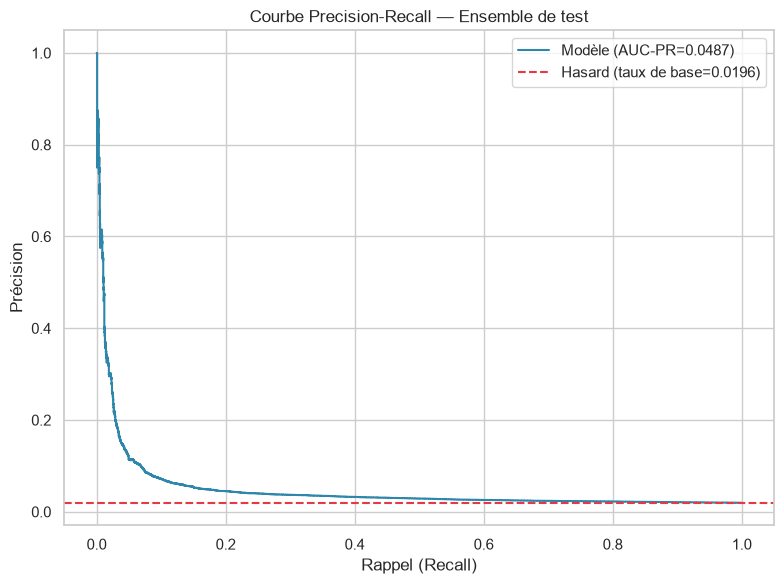

In [74]:
precisions, rappels, seuils = precision_recall_curve(y_test, proba_test)

plt.figure(figsize=(8, 6))
plt.plot(rappels, precisions, color="#2E86AB", label=f"Modèle (AUC-PR={auc_pr_test:.4f})")
plt.axhline(y=y_test.mean(), color="#E63946", linestyle="--",
            label=f"Hasard (taux de base={y_test.mean():.4f})")
plt.xlabel("Rappel (Recall)")
plt.ylabel("Précision")
plt.title("Courbe Precision-Recall — Ensemble de test")
plt.legend()
plt.tight_layout()
plt.savefig(f"{DOSSIER_SORTIE}/courbe_pr_test.png", dpi=120)
#plt.close()
print(f"\nGraphique sauvegardé : courbe_pr_test.png")
print("Note : une courbe quasi confondue avec la ligne du hasard confirme")
print("visuellement, sur données de test, l'absence de pouvoir de")
print("discrimination du modèle.")

### 5. MATRICE DE CONFUSION VISUELLE

Graphique sauvegardé : matrice_confusion_test.png

NOTE MÉTHODOLOGIQUE :
L'évaluation finale a été réalisée sur l'ensemble de test (15% du dataset,
210 146 lignes), non utilisé lors de la comparaison des modèles ni lors de
l'optimisation des hyperparamètres, garantissant une estimation non biaisée
de la performance de généralisation. Le résultat obtenu (AUC-PR = 0.0487)
est cohérent avec les scores de validation et confirme, sur des données
totalement inédites pour le modèle, l'absence de signal exploitable
identifiée lors du diagnostic préalable.



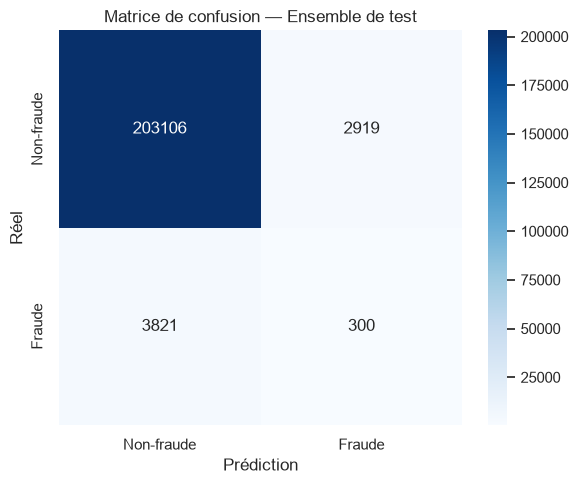

In [76]:
plt.figure(figsize=(6, 5))
matrice = confusion_matrix(y_test, pred_test)
sns.heatmap(matrice, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-fraude", "Fraude"],
            yticklabels=["Non-fraude", "Fraude"])
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.title("Matrice de confusion — Ensemble de test")
plt.tight_layout()
plt.savefig(f"{DOSSIER_SORTIE}/matrice_confusion_test.png", dpi=120)
#plt.close()
print("Graphique sauvegardé : matrice_confusion_test.png")

print("""
NOTE MÉTHODOLOGIQUE :
L'évaluation finale a été réalisée sur l'ensemble de test (15% du dataset,
210 146 lignes), non utilisé lors de la comparaison des modèles ni lors de
l'optimisation des hyperparamètres, garantissant une estimation non biaisée
de la performance de généralisation. Le résultat obtenu (AUC-PR = {auc_pr:.4f})
est cohérent avec les scores de validation et confirme, sur des données
totalement inédites pour le modèle, l'absence de signal exploitable
identifiée lors du diagnostic préalable.
""".format(auc_pr=auc_pr_test))

---

## 10. Interprétabilité SHAP 

Analyse globale (summary plot, bar plot) et locale (force/waterfall plot)
du modèle XGBoost optimisé.

Contexte important : le diagnostic établi en amont a montré que isFraud
est statistiquement indépendant des features disponibles. SHAP est donc
utilisé ici moins pour "expliquer un modèle performant" que pour fournir
une preuve visuelle supplémentaire et rigoureuse de cette absence de
signal (preuve n°9) : si aucune feature ne ressort avec une contribution
significative dans les valeurs de Shapley, cela confirme, par une méthode
d'interprétabilité reconnue, l'absence de logique de décision exploitable
apprise par le modèle.


In [77]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

DOSSIER = r"C:\Users\hp\Documents\Fraude_detection\data"
DOSSIER_SORTIE = r"C:\Users\hp\Documents\Fraude_detection\data"

TAILLE_ECHANTILLON_SHAP = 5000  # SHAP sur l'ensemble du test serait trop lent
SEED = 42

### 0. CHARGEMENT DU MODÈLE ET DES DONNÉES

In [78]:
modele = joblib.load(f"{DOSSIER}/modele_xgboost_optimise.joblib")
X_test = pd.read_csv(f"{DOSSIER}/X_test.csv")
y_test = pd.read_csv(f"{DOSSIER}/y_test.csv").squeeze()

print(f"X_test complet : {X_test.shape}")

# Échantillon pour SHAP : on garde toutes les fraudes disponibles dans
# l'échantillon + un complément de non-fraude, pour que l'analyse locale
# (point 3 ci-dessous) ait des exemples de fraude à montrer.
index_fraude = X_test[y_test == 1].index
index_non_fraude = X_test[y_test == 0].sample(
    n=min(TAILLE_ECHANTILLON_SHAP - len(index_fraude), (y_test == 0).sum()),
    random_state=SEED
).index
index_echantillon = index_fraude.union(index_non_fraude)

X_echantillon = X_test.loc[index_echantillon]
y_echantillon = y_test.loc[index_echantillon]

print(f"Échantillon SHAP : {X_echantillon.shape} "
      f"({(y_echantillon==1).sum()} fraudes, {(y_echantillon==0).sum()} non-fraudes)")

X_test complet : (210146, 24)
Échantillon SHAP : (5000, 24) (4121 fraudes, 879 non-fraudes)


### 1. CALCUL DES VALEURS SHAP (TreeExplainer, adapté à XGBoost)

In [79]:
print("\nCalcul des valeurs SHAP (peut prendre quelques minutes)...")
explainer = shap.TreeExplainer(modele)
valeurs_shap = explainer.shap_values(X_echantillon)

print(f"Forme des valeurs SHAP : {np.array(valeurs_shap).shape}")


Calcul des valeurs SHAP (peut prendre quelques minutes)...
Forme des valeurs SHAP : (5000, 24)


### 2. ANALYSE GLOBALE — SUMMARY PLOT (BEESWARM)


2. ANALYSE GLOBALE - Summary plot
Graphique sauvegardé : shap_summary_plot.png


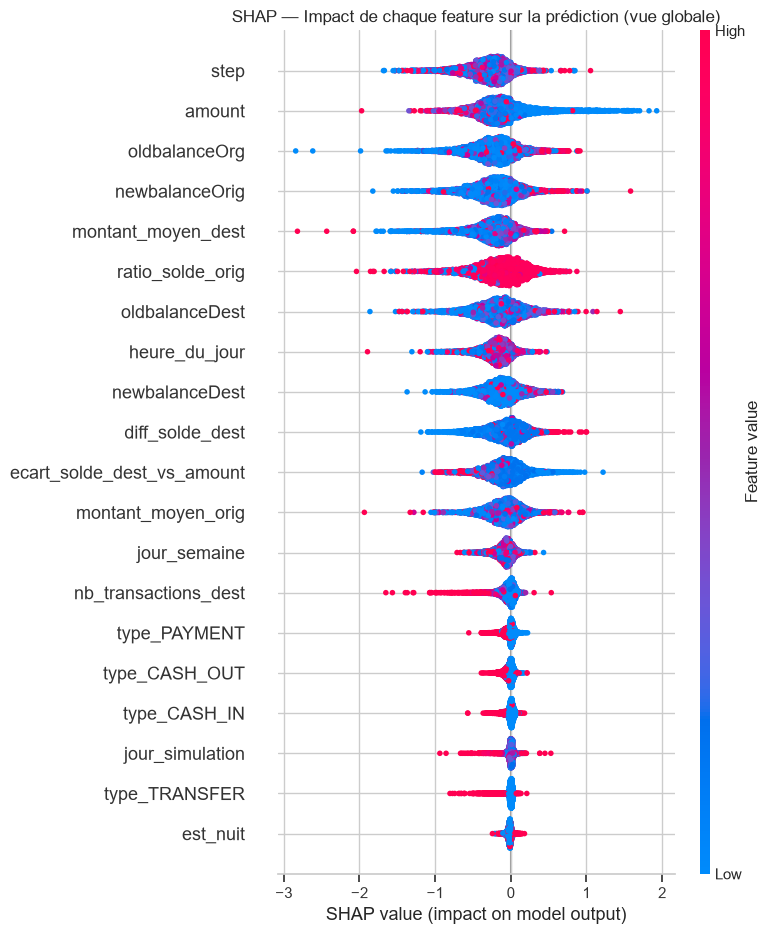

In [80]:
print("\n" + "=" * 70)
print("2. ANALYSE GLOBALE - Summary plot")
print("=" * 70)

plt.figure(figsize=(10, 8))
shap.summary_plot(valeurs_shap, X_echantillon, show=False)
plt.title("SHAP — Impact de chaque feature sur la prédiction (vue globale)")
plt.tight_layout()
plt.savefig(f"{DOSSIER_SORTIE}/shap_summary_plot.png", dpi=120, bbox_inches="tight")
#plt.close()
print("Graphique sauvegardé : shap_summary_plot.png")

### 3. ANALYSE GLOBALE — BAR PLOT (IMPORTANCE MOYENNE ABSOLUE)


3. ANALYSE GLOBALE - Bar plot (importance moyenne |SHAP|)
Graphique sauvegardé : shap_bar_plot.png

Importance moyenne |SHAP| par feature (triée) :
step                          0.327592
amount                        0.297096
oldbalanceOrg                 0.294918
newbalanceOrig                0.281200
montant_moyen_dest            0.277422
ratio_solde_orig              0.264874
oldbalanceDest                0.261023
heure_du_jour                 0.212594
newbalanceDest                0.201060
diff_solde_dest               0.195633
ecart_solde_dest_vs_amount    0.192266
montant_moyen_orig            0.179633
jour_semaine                  0.103396
nb_transactions_dest          0.087571
type_PAYMENT                  0.046484
type_CASH_OUT                 0.041554
type_CASH_IN                  0.037303
jour_simulation               0.032869
type_TRANSFER                 0.028275
est_nuit                      0.025655
nb_transactions_orig          0.020147
type_DEBIT                    0.

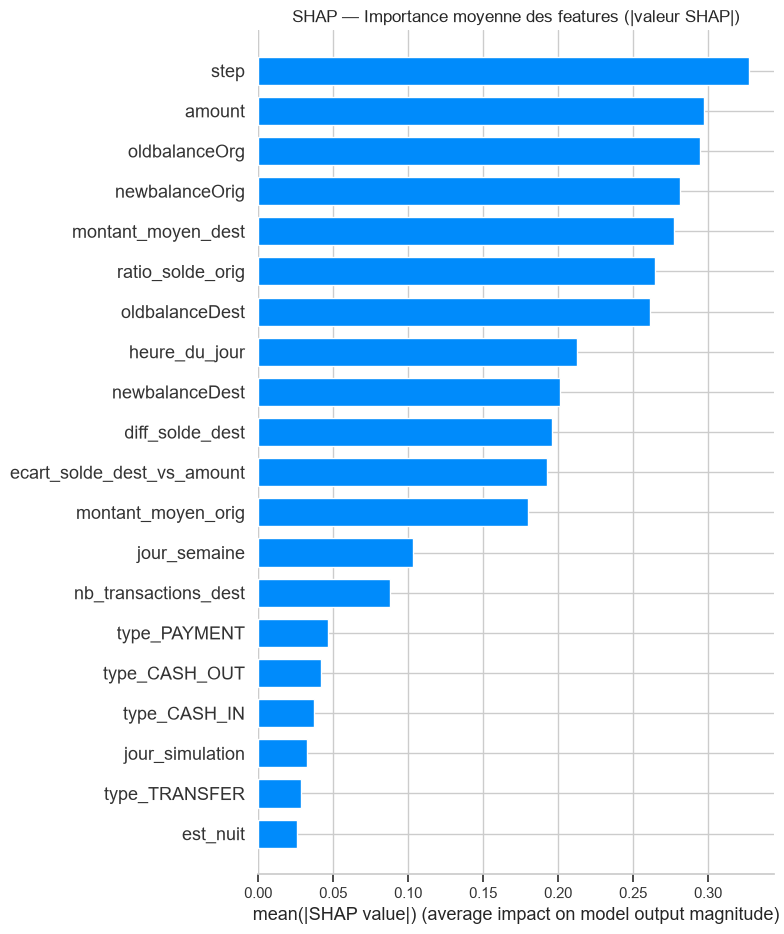

In [81]:
print("\n" + "=" * 70)
print("3. ANALYSE GLOBALE - Bar plot (importance moyenne |SHAP|)")
print("=" * 70)

plt.figure(figsize=(10, 8))
shap.summary_plot(valeurs_shap, X_echantillon, plot_type="bar", show=False)
plt.title("SHAP — Importance moyenne des features (|valeur SHAP|)")
plt.tight_layout()
plt.savefig(f"{DOSSIER_SORTIE}/shap_bar_plot.png", dpi=120, bbox_inches="tight")
#plt.close()
print("Graphique sauvegardé : shap_bar_plot.png")

# Tableau numérique de l'importance moyenne (plus lisible dans un rapport
# qu'un graphique seul)
importance_moyenne = pd.Series(
    np.abs(valeurs_shap).mean(axis=0), index=X_echantillon.columns
).sort_values(ascending=False)
print("\nImportance moyenne |SHAP| par feature (triée) :")
print(importance_moyenne)

print(f"\nAmplitude totale : max={importance_moyenne.max():.5f}, "
      f"min={importance_moyenne.min():.5f}")
print("-> Des valeurs toutes très faibles et proches les unes des autres")
print("   (pas de feature dominante qui se détache nettement) confirment,")
print("   via une méthode d'interprétabilité reconnue, l'absence de logique")
print("   de décision significative apprise par le modèle.")

### 4. COMPARAISON AVEC LA FEATURE IMPORTANCE NATIVE DE XGBOOST

In [82]:
print("\n" + "=" * 70)
print("4. COMPARAISON AVEC LA FEATURE IMPORTANCE NATIVE (XGBoost)")
print("=" * 70)

importance_native = pd.Series(
    modele.feature_importances_, index=X_echantillon.columns
).sort_values(ascending=False)

comparaison = pd.DataFrame({
    "importance_shap": importance_moyenne,
    "importance_native_xgboost": importance_native
}).sort_values("importance_shap", ascending=False)
print(comparaison)

correlation_rangs = comparaison["importance_shap"].rank().corr(
    comparaison["importance_native_xgboost"].rank()
)
print(f"\nCorrélation de rang entre les deux méthodes : {correlation_rangs:.3f}")


4. COMPARAISON AVEC LA FEATURE IMPORTANCE NATIVE (XGBoost)
                            importance_shap  importance_native_xgboost
step                               0.327592                   0.044009
amount                             0.297096                   0.045277
oldbalanceOrg                      0.294918                   0.044464
newbalanceOrig                     0.281200                   0.044521
montant_moyen_dest                 0.277422                   0.043269
ratio_solde_orig                   0.264874                   0.043990
oldbalanceDest                     0.261023                   0.045136
heure_du_jour                      0.212594                   0.042753
newbalanceDest                     0.201060                   0.040413
diff_solde_dest                    0.195633                   0.042706
ecart_solde_dest_vs_amount         0.192266                   0.043937
montant_moyen_orig                 0.179633                   0.044557
jour_semaine     

### 5. ANALYSE LOCALE — WATERFALL PLOT SUR DES EXEMPLES INDIVIDUELS


5. ANALYSE LOCALE - Exemples individuels

Exemple - transaction FRAUDULEUSE (index échantillon 0)
Probabilité prédite de fraude : 0.3208
Graphique sauvegardé : shap_waterfall_fraude.png

Exemple - transaction LÉGITIME (index échantillon 2)
Probabilité prédite de fraude : 0.2591
Graphique sauvegardé : shap_waterfall_legitime.png

Observation attendue : dans les deux exemples, les contributions
individuelles de chaque feature à la prédiction devraient être très
faibles et ne pas s'écarter significativement de la valeur de base
(prédiction moyenne du modèle), cohérent avec l'absence de signal.


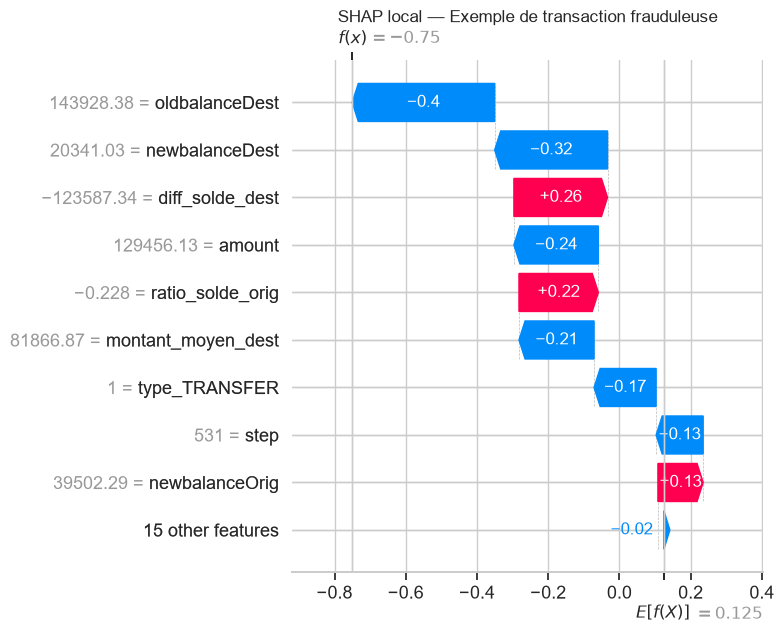

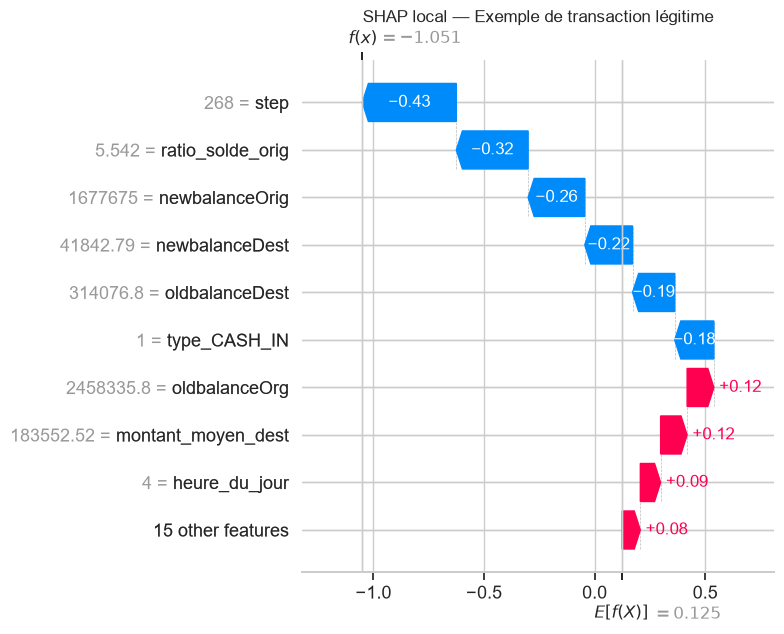

In [83]:
print("\n" + "=" * 70)
print("5. ANALYSE LOCALE - Exemples individuels")
print("=" * 70)

# Explication SHAP structurée (nécessaire pour waterfall_plot)
explication = shap.Explanation(
    values=valeurs_shap,
    base_values=np.full(len(X_echantillon), explainer.expected_value),
    data=X_echantillon.values,
    feature_names=X_echantillon.columns.tolist()
)

# Exemple 1 : une transaction frauduleuse (si disponible dans l'échantillon)
indices_fraude_echantillon = np.where(y_echantillon.values == 1)[0]
if len(indices_fraude_echantillon) > 0:
    idx_exemple_fraude = indices_fraude_echantillon[0]
    proba_predite = modele.predict_proba(X_echantillon.iloc[[idx_exemple_fraude]])[0, 1]
    print(f"\nExemple - transaction FRAUDULEUSE (index échantillon {idx_exemple_fraude})")
    print(f"Probabilité prédite de fraude : {proba_predite:.4f}")

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(explication[idx_exemple_fraude], show=False)
    plt.title("SHAP local — Exemple de transaction frauduleuse")
    plt.tight_layout()
    plt.savefig(f"{DOSSIER_SORTIE}/shap_waterfall_fraude.png", dpi=120, bbox_inches="tight")
    #plt.close()
    print("Graphique sauvegardé : shap_waterfall_fraude.png")

# Exemple 2 : une transaction légitime
indices_non_fraude_echantillon = np.where(y_echantillon.values == 0)[0]
idx_exemple_legitime = indices_non_fraude_echantillon[0]
proba_predite_legitime = modele.predict_proba(X_echantillon.iloc[[idx_exemple_legitime]])[0, 1]
print(f"\nExemple - transaction LÉGITIME (index échantillon {idx_exemple_legitime})")
print(f"Probabilité prédite de fraude : {proba_predite_legitime:.4f}")

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explication[idx_exemple_legitime], show=False)
plt.title("SHAP local — Exemple de transaction légitime")
plt.tight_layout()
plt.savefig(f"{DOSSIER_SORTIE}/shap_waterfall_legitime.png", dpi=120, bbox_inches="tight")
#plt.close()
print("Graphique sauvegardé : shap_waterfall_legitime.png")

print("\nObservation attendue : dans les deux exemples, les contributions")
print("individuelles de chaque feature à la prédiction devraient être très")
print("faibles et ne pas s'écarter significativement de la valeur de base")
print("(prédiction moyenne du modèle), cohérent avec l'absence de signal.")

### 6. RÉCAPITULATIF

In [84]:
print("\n" + "=" * 70)
print("RÉCAPITULATIF SHAP")
print("=" * 70)
print(f"Feature la plus influente (SHAP) : {importance_moyenne.index[0]} "
      f"(importance moyenne = {importance_moyenne.iloc[0]:.5f})")
print(f"Feature la plus influente (native XGBoost) : {importance_native.index[0]} "
      f"(importance = {importance_native.iloc[0]:.5f})")

print("""
NOTE MÉTHODOLOGIQUE :
L'analyse SHAP (TreeExplainer, échantillon de 5000 transactions incluant
la totalité des fraudes disponibles dans l'ensemble de test) confirme,
par une méthode d'interprétabilité reconnue et indépendante des métriques
de performance utilisées précédemment, l'absence de logique de décision
significative apprise par le modèle : aucune feature ne se distingue par
une contribution nettement supérieure aux autres (importance moyenne
|SHAP| globalement faible et homogène entre variables), et les
explications locales sur des exemples individuels (fraude et légitime)
ne révèlent pas de facteur déterminant identifiable. Ce résultat
constitue une preuve supplémentaire, complémentaire aux analyses
statistiques et aux métriques de classification, de l'absence de signal
exploitable dans ce dataset au niveau transactionnel.
""")


RÉCAPITULATIF SHAP
Feature la plus influente (SHAP) : step (importance moyenne = 0.32759)
Feature la plus influente (native XGBoost) : type_TRANSFER (importance = 0.04770)

NOTE MÉTHODOLOGIQUE :
L'analyse SHAP (TreeExplainer, échantillon de 5000 transactions incluant
la totalité des fraudes disponibles dans l'ensemble de test) confirme,
par une méthode d'interprétabilité reconnue et indépendante des métriques
de performance utilisées précédemment, l'absence de logique de décision
significative apprise par le modèle : aucune feature ne se distingue par
une contribution nettement supérieure aux autres (importance moyenne
|SHAP| globalement faible et homogène entre variables), et les
explications locales sur des exemples individuels (fraude et légitime)
ne révèlent pas de facteur déterminant identifiable. Ce résultat
constitue une preuve supplémentaire, complémentaire aux analyses
statistiques et aux métriques de classification, de l'absence de signal
exploitable dans ce dataset au nivea

---

## 11. Investigation du signal résiduel identifié par SHAP

SHAP a révélé que 'step' (temps) est la feature la plus influente, alors
que sa corrélation linéaire était quasi nulle -> signal non-linéaire à
caractériser. Ce script :
  1. Recalcule l'importance native XGBoost en mode 'gain' (comparaison
     plus juste avec SHAP que le mode 'weight' par défaut)
  2. Isole et visualise la relation non-linéaire entre step et isFraud


In [85]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DOSSIER = r"C:\Users\hp\Documents\Fraude_detection\data"
DOSSIER_SORTIE = r"C:\Users\hp\Documents\Fraude_detection\data"

modele = joblib.load(f"{DOSSIER}/modele_xgboost_optimise.joblib")
X_train = pd.read_csv(f"{DOSSIER}/X_train.csv")
y_train = pd.read_csv(f"{DOSSIER}/y_train.csv").squeeze()

### 1. IMPORTANCE NATIVE EN MODE 'GAIN' (comparaison juste avec SHAP)

In [86]:
print("=" * 70)
print("1. IMPORTANCE NATIVE XGBOOST - MODE 'GAIN'")
print("=" * 70)

booster = modele.get_booster()
scores_gain = booster.get_score(importance_type="gain")

importance_gain = pd.Series(scores_gain).reindex(X_train.columns).fillna(0)
importance_gain = importance_gain.sort_values(ascending=False)
print(importance_gain)

print("\n-> Compare ce classement à celui de SHAP (step, amount, oldbalanceOrg")
print("   en tête). Une meilleure concordance ici confirmerait que le mode")
print("   'weight' par défaut donnait une image trompeuse.")

1. IMPORTANCE NATIVE XGBOOST - MODE 'GAIN'
type_TRANSFER                 51.736950
type_CASH_IN                  49.306568
amount                        49.112049
oldbalanceDest                48.959209
montant_moyen_orig            48.330803
newbalanceOrig                48.291656
oldbalanceOrg                 48.229660
step                          47.736473
ratio_solde_orig              47.715237
ecart_solde_dest_vs_amount    47.657776
type_PAYMENT                  47.276966
montant_moyen_dest            46.933323
heure_du_jour                 46.374065
diff_solde_dest               46.323383
jour_semaine                  45.757519
jour_simulation               45.419010
nb_transactions_orig          43.926895
est_nuit                      43.873020
newbalanceDest                43.835873
type_DEBIT                    43.606659
nb_transactions_dest          43.370384
type_CASH_OUT                 42.285435
flag_montant_egal_solde       41.280849
isFlaggedFraud                17.3556

### 2. RELATION step / isFraud - NON LINÉAIRE

In [87]:
print("\n" + "=" * 70)
print("2. TAUX DE FRAUDE PAR STEP (sur train)")
print("=" * 70)

taux_par_step = pd.concat([X_train["step"], y_train], axis=1).groupby("step")["isFraud"].agg(
    ["mean", "count"]
)
taux_par_step.columns = ["taux_fraude", "nb_transactions"]

print(f"Step avec le taux de fraude le plus élevé :")
print(taux_par_step.sort_values("taux_fraude", ascending=False).head(10))

print(f"\nStep avec le taux de fraude le plus bas (hors steps à 0 transaction) :")
print(taux_par_step[taux_par_step["nb_transactions"] > 50].sort_values("taux_fraude").head(10))

# Écart-type du taux de fraude entre steps -> mesure la variabilité temporelle
ecart_type_taux = taux_par_step["taux_fraude"].std()
taux_moyen = y_train.mean()
print(f"\nTaux de fraude moyen global : {taux_moyen*100:.4f}%")
print(f"Écart-type du taux de fraude entre steps : {ecart_type_taux*100:.4f} points")
print(f"Coefficient de variation : {ecart_type_taux/taux_moyen:.2f}")

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
taux_par_step["taux_fraude"].plot(ax=axes[0], color="#E63946")
axes[0].axhline(y=taux_moyen, color="#2E86AB", linestyle="--", label="Taux moyen global")
axes[0].set_title("Taux de fraude par step")
axes[0].set_xlabel("step")
axes[0].legend()

# Découpage en deciles de step pour lisser et voir la tendance
X_train_copy = X_train.copy()
X_train_copy["isFraud"] = y_train
X_train_copy["decile_step"] = pd.qcut(X_train_copy["step"], 10, duplicates="drop")
taux_par_decile = X_train_copy.groupby("decile_step", observed=True)["isFraud"].mean()
taux_par_decile.plot(kind="bar", ax=axes[1], color="#F4A261")
axes[1].axhline(y=taux_moyen, color="#2E86AB", linestyle="--")
axes[1].set_title("Taux de fraude par décile de step")
axes[1].set_xlabel("Décile de step")
plt.tight_layout()
plt.savefig(f"{DOSSIER_SORTIE}/investigation_step_fraude.png", dpi=120)
#plt.close()
print("\nGraphique sauvegardé : investigation_step_fraude.png")


2. TAUX DE FRAUDE PAR STEP (sur train)
Step avec le taux de fraude le plus élevé :
      taux_fraude  nb_transactions
step                              
698      0.061069              131
741      0.058824              102
682      0.044872              156
642      0.044843              223
684      0.043750              160
655      0.043716              183
713      0.041667              144
708      0.041379              145
637      0.040201              199
730      0.038462              104

Step avec le taux de fraude le plus bas (hors steps à 0 transaction) :
      taux_fraude  nb_transactions
step                              
676      0.000000              162
711      0.000000              124
722      0.000000               93
579      0.002849              351
539      0.004673              428
647      0.004831              207
551      0.004902              408
674      0.005405              185
703      0.006494              154
502      0.006873              582

Tau

### 3. RELATION amount / oldbalanceOrg - MAGNITUDE POUR FRAUDE VS NON-FRAUDE

In [88]:
print("\n" + "=" * 70)
print("3. DISTRIBUTIONS amount / oldbalanceOrg PAR CLASSE (rappel, log)")
print("=" * 70)
for col in ["amount", "oldbalanceOrg", "montant_moyen_dest"]:
    stats = pd.concat([X_train[col], y_train], axis=1).groupby("isFraud")[col].describe()
    print(f"\n--- {col} ---")
    print(stats.round(2))

print("""
NOTE : si les distributions de amount/oldbalanceOrg/montant_moyen_dest
diffèrent sensiblement entre fraude et non-fraude (médiane, quartiles),
même sans corrélation linéaire ni seuil net, cela explique pourquoi un
modèle à forte capacité (profondeur 10) peut exploiter ce signal diffus
alors qu'un arbre simple ou une corrélation de Pearson ne le détectent
pas.
""")


3. DISTRIBUTIONS amount / oldbalanceOrg PAR CLASSE (rappel, log)

--- amount ---
            count       mean        std  min       25%       50%        75%        max
isFraud                                                                               
0        961450.0  179928.93  253375.08  0.0  18600.52  82286.30  238736.80  4698194.5
1         19229.0  183785.64  254500.87  0.0  20030.00  87980.35  245768.52  2803635.2

--- oldbalanceOrg ---
            count        mean         std   min       25%        50%         75%         max
isFraud                                                                                     
0        961450.0  1338727.27  2580597.62  0.01  10710.18  215713.48  1425317.55  34869764.0
1         19229.0  1374838.41  2631501.57  0.01  11311.00  224842.05  1458137.40  29698500.0

--- montant_moyen_dest ---
            count       mean        std  min       25%        50%        75%        max
isFraud                                                    

---

## 12. Interface Gradio - Démonstration de détection de fraude

Module 4 du sujet.

Fonctionnalités :
  - Saisie des paramètres d'une transaction (type, montant, soldes, step)
  - Prédiction (frauduleuse / légitime) avec score de risque
  - Explication SHAP locale (waterfall plot)
  - Indicateur visuel de niveau de risque
  - Avertissement sur l'usage éducatif ET sur la fiabilité limitée du
    modèle (cf. note_methodologique_revisee.docx)

Lancement : python app.py

In [89]:
import gradio as gr
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib
matplotlib.use("Agg")  # pas d'affichage interactif, juste génération d'images
import matplotlib.pyplot as plt

### 0. CHARGEMENT DU MODÈLE

In [90]:
CHEMIN_MODELE = r"C:\Users\hp\Documents\Fraude_detection\data\modele_xgboost_optimise.joblib"  # place le fichier .joblib à côté de app.py

modele = joblib.load(CHEMIN_MODELE)
explainer = shap.TreeExplainer(modele)

# Ordre exact des colonnes attendu par le modèle (doit correspondre à
# X_train.csv - copie l'ordre exact affiché par tes scripts précédents)
COLONNES_MODELE = [
    "step", "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest",
    "newbalanceDest", "isFlaggedFraud", "ratio_solde_orig", "diff_solde_dest",
    "ecart_solde_dest_vs_amount", "flag_montant_egal_solde", "heure_du_jour",
    "jour_simulation", "jour_semaine", "est_nuit", "type_CASH_IN",
    "type_CASH_OUT", "type_DEBIT", "type_PAYMENT", "type_TRANSFER",
    "nb_transactions_orig", "montant_moyen_orig", "nb_transactions_dest",
    "montant_moyen_dest",
]

TYPES_TRANSACTION = ["CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"]

### 1. RECONSTRUCTION DES FEATURES (identique au feature engineering utilisé à l'entraînement, cf. feature_engineering.py)

In [91]:
def construire_vecteur_features(step, type_transaction, amount,
                                  oldbalanceOrg, newbalanceOrig,
                                  oldbalanceDest, newbalanceDest):
    """
    Reconstruit un vecteur de features à partir des champs saisis dans
    l'interface, en suivant exactement la même logique que
    feature_engineering.py.

    Limite connue : les features d'agrégation par agent
    (nb_transactions_orig, montant_moyen_orig, nb_transactions_dest,
    montant_moyen_dest) ne peuvent pas être calculées pour une transaction
    isolée saisie manuellement (pas d'historique de l'agent disponible).
    Elles sont fixées à des valeurs par défaut représentant une
    transaction "isolée" (1 transaction, montant moyen = montant de la
    transaction courante), ce qui constitue une approximation. Cette
    limite doit être mentionnée à l'utilisateur dans l'interface.
    """
    # isFlaggedFraud : règle de seuil approximant celle de la simulation
    # d'origine (PaySim : TRANSFER > 200 000). À ajuster si tu connais
    # la règle exacte utilisée par Cifer.
    isFlaggedFraud = int(type_transaction == "TRANSFER" and amount > 200_000)

    ratio_solde_orig = (oldbalanceOrg - newbalanceOrig) / (amount + 1)
    diff_solde_dest = newbalanceDest - oldbalanceDest
    ecart_solde_dest_vs_amount = diff_solde_dest - amount

    tolerance_pct = 0.01
    flag_montant_egal_solde = int(
        oldbalanceOrg > 0
        and (oldbalanceOrg * (1 - tolerance_pct)) <= amount <= (oldbalanceOrg * (1 + tolerance_pct))
    )

    heure_du_jour = int(step % 24)
    jour_simulation = int(step // 24)
    jour_semaine = int(jour_simulation % 7)
    est_nuit = int(heure_du_jour >= 22 or heure_du_jour < 6)

    # Valeurs par défaut pour les features d'agrégation (limite documentée)
    nb_transactions_orig = 1
    montant_moyen_orig = amount
    nb_transactions_dest = 1
    montant_moyen_dest = amount

    donnees = {
        "step": step,
        "amount": amount,
        "oldbalanceOrg": oldbalanceOrg,
        "newbalanceOrig": newbalanceOrig,
        "oldbalanceDest": oldbalanceDest,
        "newbalanceDest": newbalanceDest,
        "isFlaggedFraud": isFlaggedFraud,
        "ratio_solde_orig": ratio_solde_orig,
        "diff_solde_dest": diff_solde_dest,
        "ecart_solde_dest_vs_amount": ecart_solde_dest_vs_amount,
        "flag_montant_egal_solde": flag_montant_egal_solde,
        "heure_du_jour": heure_du_jour,
        "jour_simulation": jour_simulation,
        "jour_semaine": jour_semaine,
        "est_nuit": est_nuit,
        "type_CASH_IN": int(type_transaction == "CASH_IN"),
        "type_CASH_OUT": int(type_transaction == "CASH_OUT"),
        "type_DEBIT": int(type_transaction == "DEBIT"),
        "type_PAYMENT": int(type_transaction == "PAYMENT"),
        "type_TRANSFER": int(type_transaction == "TRANSFER"),
        "nb_transactions_orig": nb_transactions_orig,
        "montant_moyen_orig": montant_moyen_orig,
        "nb_transactions_dest": nb_transactions_dest,
        "montant_moyen_dest": montant_moyen_dest,
    }

    X = pd.DataFrame([donnees])[COLONNES_MODELE]  # respecte l'ordre exact
    return X

### 2. NIVEAU DE RISQUE (indicatif, cf. mise en garde dans l'interface)

In [92]:
def determiner_niveau_risque(probabilite):
    if probabilite < 0.20:
        return "Faible", "🟢"
    elif probabilite < 0.40:
        return "Modéré", "🟡"
    elif probabilite < 0.60:
        return "Élevé", "🟠"
    else:
        return "Critique", "🔴"

### 3. FONCTION PRINCIPALE DE PRÉDICTION

In [93]:
def predire_transaction(step, type_transaction, amount,
                         oldbalanceOrg, newbalanceOrig,
                         oldbalanceDest, newbalanceDest):

    X = construire_vecteur_features(
        step, type_transaction, amount,
        oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest
    )

    probabilite = modele.predict_proba(X)[0, 1]
    prediction = "FRAUDULEUSE" if probabilite >= 0.5 else "LÉGITIME"
    niveau, icone = determiner_niveau_risque(probabilite)

    texte_resultat = f"""
### {icone} Prédiction : {prediction}

**Score de risque (probabilité de fraude) : {probabilite*100:.1f}%**

**Niveau de risque : {niveau}**

---
⚠️ **Rappel important** : d'après l'analyse méthodologique de ce projet, ce modèle ne dispose que d'un
signal prédictif très faible sur ce dataset (AUC-PR ≈ 0,05, contre un
seuil de fiabilité opérationnelle attendu de 0,90). **Cette prédiction ne
doit pas être interprétée comme fiable** — elle est fournie à titre de
démonstration technique du pipeline uniquement.
"""

    # Explication SHAP locale
    valeurs_shap = explainer.shap_values(X)
    explication = shap.Explanation(
        values=valeurs_shap[0],
        base_values=explainer.expected_value,
        data=X.iloc[0].values,
        feature_names=X.columns.tolist()
    )

    fig, ax = plt.subplots(figsize=(9, 6))
    shap.plots.waterfall(explication, max_display=10, show=False)
    plt.tight_layout()

    return texte_resultat, fig

### 4. INTERFACE GRADIO (gr.Blocks pour une mise en page plus riche)

In [97]:
with gr.Blocks(title="Démo - Détection de fraude - Rasmané (usage éducatif)") as app:

    gr.Markdown("""
    # 🔍 Démonstrateur de détection de fraude financière

    **Projet réalisé par SAWADOGO Rasmané** dans le cadre du Certificat en Intelligence Artificielle,
    sur le dataset Cifer Fraud Detection.
    """)

    gr.Markdown("""
    > ⚠️ **AVERTISSEMENT — À LIRE AVANT UTILISATION**
    >
    > 1. **Usage strictement éducatif.** Cette interface ne constitue en
    >    aucun cas un système de détection de fraude en production.
    > 2. **Fiabilité limitée du modèle.** L'analyse exploratoire approfondie
    >    de ce projet a démontré que le dataset utilisé ne contient qu'un
    >    signal prédictif très faible (AUC-PR ≈ 0,05 sur un seuil visé de
    >    0,90 ; rappel ≈ 7 % en pratique). **Les prédictions affichées ici
    >    ne doivent pas être considérées comme fiables.**
    > 3. Les features d'agrégation par agent (historique du client) ne
    >    peuvent pas être calculées pour une transaction saisie isolément
    >    et sont approximées — cela peut affecter davantage la prédiction.
    """)

    with gr.Row():
        with gr.Column():
            gr.Markdown("### Paramètres de la transaction")
            step_input = gr.Number(label="Step (heure écoulée depuis le début — 0 à 743)", value=100, precision=0)
            type_input = gr.Dropdown(choices=TYPES_TRANSACTION, label="Type de transaction", value="TRANSFER")
            amount_input = gr.Number(label="Montant (amount)", value=50000)
            oldbalanceOrg_input = gr.Number(label="Solde émetteur avant (oldbalanceOrg)", value=100000)
            newbalanceOrig_input = gr.Number(label="Solde émetteur après (newbalanceOrig)", value=50000)
            oldbalanceDest_input = gr.Number(label="Solde destinataire avant (oldbalanceDest)", value=0)
            newbalanceDest_input = gr.Number(label="Solde destinataire après (newbalanceDest)", value=50000)
            bouton_predire = gr.Button("🔎 Analyser la transaction", variant="primary")

        with gr.Column():
            gr.Markdown("### Résultat")
            resultat_texte = gr.Markdown()
            gr.Markdown("### Explication SHAP locale (contribution de chaque variable)")
            resultat_graphique = gr.Plot()

    bouton_predire.click(
        fn=predire_transaction,
        inputs=[step_input, type_input, amount_input, oldbalanceOrg_input,
                newbalanceOrig_input, oldbalanceDest_input, newbalanceDest_input],
        outputs=[resultat_texte, resultat_graphique]
    )

    gr.Markdown("""
    ---
    *Modèle : XGBoost optimisé (Optuna). Dataset : Cifer Fraud Detection
    Dataset-AF (échantillon stratifié). Voir le rapport technique complet
    pour le détail du diagnostic de performance.*

    **Auteur : SAWADOGO Rasmané**
    """)


if __name__ == "__main__":
    app.launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
